#Olist Brazilian E-Commerce — Apache Spark Data Integration Pipeline

**Student Name    :** Rohit Kumar  
**Student ID      :** GH1029908
**Module          :** Big Data Management / Data Integration  
**Dataset Source  :** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
**GitHub Repo     :** [Your GitHub Repository URL]  
**Video Demo      :** [Your Video URL]


---
##CELL 0: Loading Dataset direcly using url.
---
###Source: Kaggle public dataset (olistbr/brazilian-ecommerce)

My Approach to This Project:
I particularly chose the Oilst dataset because I was genuinely keen to klnow about how e-commerce works in Brazil. This was a market or lets say a domain I have never worked in, throught this project I ran into very interesting findings and knowledge.

The biggest challenge I ran across was realising that joining the payments table directly to orders was inflating my revenue figures by about 5x. It took me a whilw to figure out why the numbers looked wrong, and the solution "pre-aggregating payments before the join" was something I worked out by printing intermediate row counts and comparing them.

I also found the delivery delay analysis the most interestinbg part. I expected late deliveries to corelate with lower scores but I did not expect the drop to be that sharp, orders more than 14 days late averaging below 2.5 stars was a stronger finding than I anticipated.



In [ ]:
import os
import urllib.request
import zipfile

RAW_DATA_PATH = "/content/olist_data/raw"
os.makedirs(RAW_DATA_PATH, exist_ok=True)

# Hosted publicly on GitHub by the Olist team
BASE_URL = "https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets"

FILES = {
    "olist_orders_dataset.csv"               : f"{BASE_URL}/olist_orders_dataset.csv",
    "olist_order_items_dataset.csv"          : f"{BASE_URL}/olist_order_items_dataset.csv",
    "olist_customers_dataset.csv"            : f"{BASE_URL}/olist_customers_dataset.csv",
    "olist_products_dataset.csv"             : f"{BASE_URL}/olist_products_dataset.csv",
    "olist_sellers_dataset.csv"              : f"{BASE_URL}/olist_sellers_dataset.csv",
    "olist_order_payments_dataset.csv"       : f"{BASE_URL}/olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv"        : f"{BASE_URL}/olist_order_reviews_dataset.csv",
    "olist_geolocation_dataset.csv"          : f"{BASE_URL}/olist_geolocation_dataset.csv",
    "product_category_name_translation.csv"  : f"{BASE_URL}/product_category_name_translation.csv",
}

print("Downloading Olist dataset files...")
print(f"{'File':<55} {'Size':>8}")
print("-" * 66)

for fname, url in FILES.items():
    dest = f"{RAW_DATA_PATH}/{fname}"
    urllib.request.urlretrieve(url, dest)
    size_mb = os.path.getsize(dest) / 1_000_000
    print(f"  {fname:<53} {size_mb:>6.1f} MB")

print("\nAll files downloaded. Ready to run pipeline.")

File                                                        Size
------------------------------------------------------------------
  olist_orders_dataset.csv                                17.7 MB
  olist_order_items_dataset.csv                           15.0 MB
  olist_customers_dataset.csv                              8.6 MB
  olist_products_dataset.csv                               2.4 MB
  olist_sellers_dataset.csv                                0.2 MB
  olist_order_payments_dataset.csv                         5.6 MB
  olist_order_reviews_dataset.csv                         14.5 MB
  olist_geolocation_dataset.csv                           61.3 MB
  product_category_name_translation.csv                    0.0 MB

All files downloaded. Ready to run pipeline.


---
##CELL 1: Install PySpark and initialise Spark session
---
shuffle.partitions=8  -> tuned for ~100K rows on single node

driver.memory=4g      -> prevents OOM on geolocation table

In [ ]:
!pip install pyspark --quiet

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType
)

spark = SparkSession.builder \
    .appName("Olist_Brazilian_Ecommerce_Pipeline") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(f"PySpark version  : {pyspark.__version__}")
print(f"Spark app name   : {spark.sparkContext.appName}")
print(f"Available cores  : {spark.sparkContext.defaultParallelism}")

PySpark version  : 4.0.3
Spark app name   : Olist_Brazilian_Ecommerce_Pipeline
Available cores  : 2


#Phase 4 — Environment Setup and Data Ingestion

---
##CELL 2: Configuration Hub of entire pipeline
---

I seperated input into local Colab storage and output into Google drive to the sessions so outputs can be saved permanently, it defines all file paths in one place so nothing is hardcoded elsewhere in the notebook. Inputs are momentary, I can always re-download them. It is the same principle as a data lake where raw and processed layers are stored differently based on how they were produced and how likely they are to be reused.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
from datetime import datetime

# Input paths (local Colab — fast read)
BASE_PATH = "/content/olist_data/raw"

FILE_PATHS = {
    "orders"      : f"{BASE_PATH}/olist_orders_dataset.csv",
    "order_items" : f"{BASE_PATH}/olist_order_items_dataset.csv",
    "customers"   : f"{BASE_PATH}/olist_customers_dataset.csv",
    "products"    : f"{BASE_PATH}/olist_products_dataset.csv",
    "sellers"     : f"{BASE_PATH}/olist_sellers_dataset.csv",
    "payments"    : f"{BASE_PATH}/olist_order_payments_dataset.csv",
    "reviews"     : f"{BASE_PATH}/olist_order_reviews_dataset.csv",
    "geolocation" : f"{BASE_PATH}/olist_geolocation_dataset.csv",
    "category_tr" : f"{BASE_PATH}/product_category_name_translation.csv",
}

# Output paths (Google Drive — persistent)
BASE_OUTPUT = "/content/drive/MyDrive/olist_data/processed"
VIZ_PATH    = "/content/drive/MyDrive/olist_data/visualisations"

PATHS = {
    "integrated"   : f"{BASE_OUTPUT}/olist_integrated.parquet",
    "aggregated"   : f"{BASE_OUTPUT}/olist_aggregated.parquet",
    "orders_clean" : f"{BASE_OUTPUT}/orders_clean.parquet",
    "items_clean"  : f"{BASE_OUTPUT}/order_items_clean.parquet",
    "reviews_clean": f"{BASE_OUTPUT}/reviews_clean.parquet",
}

# Pipeline constants
TIMESTAMP_FORMAT    = "yyyy-MM-dd HH:mm:ss"
PARQUET_COMPRESSION = "snappy"
PARQUET_MODE        = "overwrite"
IQR_MULTIPLIER      = 3.0
SELLER_MIN_ORDERS   = 50
GEO_LAT_MIN, GEO_LAT_MAX = -33.75,  5.27
GEO_LNG_MIN, GEO_LNG_MAX = -73.99, -28.85

VALID_STATUSES = [
    "delivered", "shipped", "canceled", "unavailable",
    "invoiced",  "processing", "created", "approved"
]

os.makedirs(BASE_OUTPUT, exist_ok=True)
os.makedirs(VIZ_PATH,    exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID   : {RUN_ID}")
print(f"Input    : {BASE_PATH}")
print(f"Output   : {BASE_OUTPUT}")
print(f"Charts   : {VIZ_PATH}")

Mounted at /content/drive
Run ID   : 20260625_030055
Input    : /content/olist_data/raw
Output   : /content/drive/MyDrive/olist_data/processed
Charts   : /content/drive/MyDrive/olist_data/visualisations


---
##CELL 3: Explicit schema definitions for all 9 tables
---
In this cell, I defined nine fixed schemas, one for each CSV file. Instead of using `inferSchema` and letting Spark guess the data types, I manually defined the column types before loading the data.

I did this because `inferSchema` can make Spark scan the data more than once, which adds extra processing time. By defining the schemas upfront, I avoid that extra scan, reduce the chance of incorrect type guesses, and make the expected structure of each table clear from the beginning.

I mainly used three data types in these schemas. I used `StringType` for text values and identifiers, `IntegerType` for whole numbers such as counts and scores, and `DoubleType` for decimal values such as prices and location coordinates.

I loaded all timestamp columns as `StringType` on purpose. Spark can sometimes fail to parse dates correctly if the format does not match exactly, which can silently turn those values into nulls. To avoid this, I decided to convert the timestamp fields later in Phase 5 using a specific date format.

I also kept zip code columns as `StringType` because some zip codes can start with zero. If they were loaded as numbers, those leading zeros would be removed.

In the products table, there are also misspelled column names, such as `lenght` instead of `length`. I kept those names unchanged during ingestion because they match the original Kaggle dataset. I corrected them later in Phase 5.



In [ ]:
schema_orders = StructType([
    StructField("order_id",                       StringType(),  True),
    StructField("customer_id",                    StringType(),  True),
    StructField("order_status",                   StringType(),  True),
    StructField("order_purchase_timestamp",       StringType(),  True),
    StructField("order_approved_at",              StringType(),  True),
    StructField("order_delivered_carrier_date",   StringType(),  True),
    StructField("order_delivered_customer_date",  StringType(),  True),
    StructField("order_estimated_delivery_date",  StringType(),  True),
])

schema_order_items = StructType([
    StructField("order_id",            StringType(),  True),
    StructField("order_item_id",       IntegerType(), True),
    StructField("product_id",          StringType(),  True),
    StructField("seller_id",           StringType(),  True),
    StructField("shipping_limit_date", StringType(),  True),
    StructField("price",               DoubleType(),  True),
    StructField("freight_value",       DoubleType(),  True),
])

schema_customers = StructType([
    StructField("customer_id",              StringType(), True),
    StructField("customer_unique_id",       StringType(), True),
    StructField("customer_zip_code_prefix", StringType(), True),
    StructField("customer_city",            StringType(), True),
    StructField("customer_state",           StringType(), True),
])

schema_products = StructType([
    StructField("product_id",                 StringType(),  True),
    StructField("product_category_name",      StringType(),  True),
    StructField("product_name_lenght",        IntegerType(), True),
    StructField("product_description_lenght", IntegerType(), True),
    StructField("product_photos_qty",         IntegerType(), True),
    StructField("product_weight_g",           IntegerType(), True),
    StructField("product_length_cm",          IntegerType(), True),
    StructField("product_height_cm",          IntegerType(), True),
    StructField("product_width_cm",           IntegerType(), True),
])

schema_sellers = StructType([
    StructField("seller_id",              StringType(), True),
    StructField("seller_zip_code_prefix", StringType(), True),
    StructField("seller_city",            StringType(), True),
    StructField("seller_state",           StringType(), True),
])

schema_payments = StructType([
    StructField("order_id",             StringType(),  True),
    StructField("payment_sequential",   IntegerType(), True),
    StructField("payment_type",         StringType(),  True),
    StructField("payment_installments", IntegerType(), True),
    StructField("payment_value",        DoubleType(),  True),
])

schema_reviews = StructType([
    StructField("review_id",               StringType(),  True),
    StructField("order_id",                StringType(),  True),
    StructField("review_score",            IntegerType(), True),
    StructField("review_comment_title",    StringType(),  True),
    StructField("review_comment_message",  StringType(),  True),
    StructField("review_creation_date",    StringType(),  True),
    StructField("review_answer_timestamp", StringType(),  True),
])

schema_geolocation = StructType([
    StructField("geolocation_zip_code_prefix", StringType(), True),
    StructField("geolocation_lat",             DoubleType(), True),
    StructField("geolocation_lng",             DoubleType(), True),
    StructField("geolocation_city",            StringType(), True),
    StructField("geolocation_state",           StringType(), True),
])

schema_category_tr = StructType([
    StructField("product_category_name",         StringType(), True),
    StructField("product_category_name_english", StringType(), True),
])

print("All 9 schemas defined successfully.")

All 9 schemas defined successfully.


---
##CELL 4: Load all 9 CSV files into PySpark DataFrames
---
In Cell 4, I created a reusable `load_csv` function to load all nine CSV files in a consistent way. The function applies common options such as reading headers, using UTF-8 encoding for Portuguese characters, handling quotation marks with an escape character, and applying the schemas defined in Cell 3.

I used `multiLine=True` only for the reviews table because customer comments may contain line breaks. This prevents Spark from reading one review as multiple rows. I did not apply it to the other tables to avoid unnecessary overhead.

Since Spark uses lazy evaluation, the files are not actually read in this cell. They are only loaded later when Cell 5 triggers an action.



In [ ]:
def load_csv(path, schema, multiline=False):
    """Utility loader with consistent options for all tables."""
    return (
        spark.read
        .option("header",    "true")
        .option("encoding",  "UTF-8")
        .option("multiLine", str(multiline).lower())
        .option("escape",    '"')
        .schema(schema)
        .csv(path)
    )

df_orders      = load_csv(FILE_PATHS["orders"],      schema_orders)
df_items       = load_csv(FILE_PATHS["order_items"], schema_order_items)
df_customers   = load_csv(FILE_PATHS["customers"],   schema_customers)
df_products    = load_csv(FILE_PATHS["products"],    schema_products)
df_sellers     = load_csv(FILE_PATHS["sellers"],     schema_sellers)
df_payments    = load_csv(FILE_PATHS["payments"],    schema_payments)
df_reviews     = load_csv(FILE_PATHS["reviews"],     schema_reviews,   multiline=True)
df_geolocation = load_csv(FILE_PATHS["geolocation"], schema_geolocation)
df_category_tr = load_csv(FILE_PATHS["category_tr"], schema_category_tr)

print("All 9 DataFrames loaded successfully.")

All 9 DataFrames loaded successfully.


---
##CELL 5: Raw data inventory — establishes baseline before cleaning
---

In [ ]:
raw_tables = {
    "orders"      : df_orders,
    "order_items" : df_items,
    "customers"   : df_customers,
    "products"    : df_products,
    "sellers"     : df_sellers,
    "payments"    : df_payments,
    "reviews"     : df_reviews,
    "geolocation" : df_geolocation,
    "category_tr" : df_category_tr,
}

print(f"{'Table':<18} {'Rows':>10} {'Columns':>10}")
print("-" * 42)
total_rows = 0
for name, df in raw_tables.items():
    cnt = df.count()
    total_rows += cnt
    print(f"{name:<18} {cnt:>10,} {len(df.columns):>10}")
print("-" * 42)
print(f"{'TOTAL':<18} {total_rows:>10,}")

Table                    Rows    Columns
------------------------------------------
orders                 99,441          8
order_items           112,650          7
customers              99,441          5
products               32,951          9
sellers                 3,095          4
payments              103,886          5
reviews                99,224          7
geolocation         1,000,163          5
category_tr                71          2
------------------------------------------
TOTAL               1,550,922


---
##CELL 6: Schema inspection and sample preview
---

In [ ]:
print("=== ORDERS schema ===")
df_orders.printSchema()

print("\n=== ORDERS sample (5 rows) ===")
df_orders.show(5, truncate=40)

print("\n=== ORDER ITEMS sample (5 rows) ===")
df_items.show(5, truncate=40)

print("\n=== REVIEWS sample (3 rows) ===")
df_reviews.show(3, truncate=60)

print("\n=== CATEGORY TRANSLATION ===")
df_category_tr.show(71, truncate=False)

=== ORDERS schema ===
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: string (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: string (nullable = true)
 |-- order_estimated_delivery_date: string (nullable = true)


=== ORDERS sample (5 rows) ===
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|                        order_id|                     customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+----------------

---
##CELL 7: Register raw DataFrames as Spark SQL temp views
---

In [ ]:
for name, df in raw_tables.items():
    df.createOrReplaceTempView(name)

print("Raw temp views registered:")
for name in raw_tables:
    print(f"  SELECT * FROM {name}")

Raw temp views registered:
  SELECT * FROM orders
  SELECT * FROM order_items
  SELECT * FROM customers
  SELECT * FROM products
  SELECT * FROM sellers
  SELECT * FROM payments
  SELECT * FROM reviews
  SELECT * FROM geolocation
  SELECT * FROM category_tr


---
##CELL 8: Null count baseline scan across all raw tables
---

In [ ]:
print("=== NULL COUNT SCAN — RAW INGESTION BASELINE ===\n")

for name, df in raw_tables.items():
    null_counts = df.select([
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    row = null_counts.collect()[0].asDict()
    flagged = {k: v for k, v in row.items() if v > 0}
    if flagged:
        print(f"[{name}] nulls detected:")
        for col, cnt in flagged.items():
            print(f"    {col:<45} {cnt:>6,} nulls")
    else:
        print(f"[{name}] no nulls in raw data.")
    print()

=== NULL COUNT SCAN — RAW INGESTION BASELINE ===

[orders] nulls detected:
    order_approved_at                                160 nulls
    order_delivered_carrier_date                   1,783 nulls
    order_delivered_customer_date                  2,965 nulls

[order_items] no nulls in raw data.

[customers] no nulls in raw data.

[products] nulls detected:
    product_category_name                            610 nulls
    product_name_lenght                              610 nulls
    product_description_lenght                       610 nulls
    product_photos_qty                               610 nulls
    product_weight_g                                   2 nulls
    product_length_cm                                  2 nulls
    product_height_cm                                  2 nulls
    product_width_cm                                   2 nulls

[sellers] no nulls in raw data.

[payments] no nulls in raw data.

[reviews] nulls detected:
    review_comment_title              

#Phase 5 — Data Cleaning and Preprocessing

---
##CELL 9: Timestamp casting — StringType -> TimestampType
---
In this cell, I have converted the timestamp columns from text into proper Spark date values using a clear date format. I do this after ingestion to avoid Spark silently creating nulls during automatic parsing. After conversion, I checked for nulls, and the result shows zero new nulls, meaning all timestamps were parsed correctly.



In [ ]:
df_orders_typed = df_orders \
    .withColumn("order_purchase_timestamp",
        F.to_timestamp("order_purchase_timestamp", TIMESTAMP_FORMAT)) \
    .withColumn("order_approved_at",
        F.to_timestamp("order_approved_at", TIMESTAMP_FORMAT)) \
    .withColumn("order_delivered_carrier_date",
        F.to_timestamp("order_delivered_carrier_date", TIMESTAMP_FORMAT)) \
    .withColumn("order_delivered_customer_date",
        F.to_timestamp("order_delivered_customer_date", TIMESTAMP_FORMAT)) \
    .withColumn("order_estimated_delivery_date",
        F.to_timestamp("order_estimated_delivery_date", TIMESTAMP_FORMAT))

df_reviews_typed = df_reviews \
    .withColumn("review_creation_date",
        F.to_timestamp("review_creation_date", TIMESTAMP_FORMAT)) \
    .withColumn("review_answer_timestamp",
        F.to_timestamp("review_answer_timestamp", TIMESTAMP_FORMAT))

df_items_typed = df_items \
    .withColumn("shipping_limit_date",
        F.to_timestamp("shipping_limit_date", TIMESTAMP_FORMAT))

# Verify: count nulls introduced by failed casts
ts_cols = ["order_purchase_timestamp", "order_approved_at",
           "order_delivered_customer_date", "order_estimated_delivery_date"]
print("=== TIMESTAMP CAST — NULL CHECK ===")
df_orders_typed.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in ts_cols
]).show()
print("Timestamp casting complete.")

=== TIMESTAMP CAST — NULL CHECK ===
+------------------------+-----------------+-----------------------------+-----------------------------+
|order_purchase_timestamp|order_approved_at|order_delivered_customer_date|order_estimated_delivery_date|
+------------------------+-----------------+-----------------------------+-----------------------------+
|                       0|              160|                         2965|                            0|
+------------------------+-----------------+-----------------------------+-----------------------------+

Timestamp casting complete.


---
##CELL 10: Duplicate removal — table-specific PK strategies
---

In [ ]:
def dedup_report(name, before_df, after_df):
    b = before_df.count()
    a = after_df.count()
    pct = (b - a) / b * 100 if b > 0 else 0
    print(f"  {name:<18} before:{b:>8,}  after:{a:>8,}  "
          f"removed:{b-a:>7,}  ({pct:.2f}%)")

print("=== DUPLICATE REMOVAL REPORT ===\n")

df_orders_dedup    = df_orders_typed.dropDuplicates(["order_id"])
df_items_dedup     = df_items_typed.dropDuplicates(["order_id", "order_item_id"])
df_customers_dedup = df_customers.dropDuplicates(["customer_id"])
df_products_dedup  = df_products.dropDuplicates(["product_id"])
df_sellers_dedup   = df_sellers.dropDuplicates(["seller_id"])
df_reviews_dedup   = df_reviews_typed.dropDuplicates(["review_id"])
df_payments_dedup  = df_payments.dropDuplicates(["order_id", "payment_sequential"])
df_geo_dedup       = df_geolocation.dropDuplicates([
    "geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"])

dedup_report("orders",      df_orders_typed,  df_orders_dedup)
dedup_report("order_items", df_items_typed,   df_items_dedup)
dedup_report("customers",   df_customers,     df_customers_dedup)
dedup_report("products",    df_products,      df_products_dedup)
dedup_report("sellers",     df_sellers,       df_sellers_dedup)
dedup_report("reviews",     df_reviews_typed, df_reviews_dedup)
dedup_report("payments",    df_payments,      df_payments_dedup)
dedup_report("geolocation", df_geolocation,   df_geo_dedup)

=== DUPLICATE REMOVAL REPORT ===

  orders             before:  99,441  after:  99,441  removed:      0  (0.00%)
  order_items        before: 112,650  after: 112,650  removed:      0  (0.00%)
  customers          before:  99,441  after:  99,441  removed:      0  (0.00%)
  products           before:  32,951  after:  32,951  removed:      0  (0.00%)
  sellers            before:   3,095  after:   3,095  removed:      0  (0.00%)
  reviews            before:  99,224  after:  98,410  removed:    814  (0.82%)
  payments           before: 103,886  after: 103,886  removed:      0  (0.00%)
  geolocation        before:1,000,163  after: 720,154  removed:280,009  (28.00%)


---
##CELL 11: Missing value handling
---
In this cell, I handled null values based on what they actually mean. I drop rows with null order IDs because they are not useful, fill missing city names with `unknown` because the row still has value, and keep null delivery dates because they show orders that have not been delivered yet. This cell treats each null based on its context instead of handling all missing values the same way.



In [ ]:
# ORDERS
df_orders_clean = df_orders_dedup \
    .dropna(subset=["order_id", "customer_id", "order_purchase_timestamp"]) \
    .filter(F.col("order_status").isin(VALID_STATUSES))

# ORDER ITEMS
df_items_clean = df_items_dedup \
    .dropna(subset=["order_id", "product_id", "seller_id", "price"]) \
    .fillna({"freight_value": 0.0}) \
    .filter((F.col("price") >= 0) & (F.col("freight_value") >= 0))

# CUSTOMERS
df_customers_clean = df_customers_dedup \
    .dropna(subset=["customer_id", "customer_state"]) \
    .fillna({"customer_city": "unknown", "customer_zip_code_prefix": "00000"})

# PRODUCTS
df_products_clean = df_products_dedup \
    .dropna(subset=["product_id"]) \
    .fillna({
        "product_category_name"      : "uncategorised",
        "product_weight_g"           : 0,
        "product_length_cm"          : 0,
        "product_height_cm"          : 0,
        "product_width_cm"           : 0,
        "product_photos_qty"         : 0,
        "product_name_lenght"        : 0,
        "product_description_lenght" : 0,
    }) \
    .withColumnRenamed("product_name_lenght",        "product_name_length") \
    .withColumnRenamed("product_description_lenght", "product_description_length")

# SELLERS
df_sellers_clean = df_sellers_dedup.dropna(subset=["seller_id"])

# PAYMENTS
df_payments_clean = df_payments_dedup \
    .dropna(subset=["order_id", "payment_value"]) \
    .fillna({"payment_type": "unknown", "payment_installments": 1}) \
    .filter(F.col("payment_value") > 0)

# REVIEWS
df_reviews_clean = df_reviews_dedup \
    .dropna(subset=["order_id", "review_score"]) \
    .fillna({"review_comment_title": "no title",
             "review_comment_message": "no comment"}) \
    .filter(F.col("review_score").between(1, 5))

# GEOLOCATION
df_geo_clean = df_geo_dedup \
    .dropna(subset=["geolocation_zip_code_prefix",
                    "geolocation_lat", "geolocation_lng"]) \
    .filter(
        F.col("geolocation_lat").between(GEO_LAT_MIN, GEO_LAT_MAX) &
        F.col("geolocation_lng").between(GEO_LNG_MIN, GEO_LNG_MAX))

# CATEGORY TRANSLATION
df_category_clean = df_category_tr.dropna()

print("Missing value handling complete.")

Missing value handling complete.


---
##CELL 12: Outlier filter on price column (3xIQR method)
---
3xIQR is preferred over z-score for right-skewed price data.


In [ ]:
price_stats = df_items_clean.select(
    F.expr("percentile_approx(price, 0.25)").alias("q1"),
    F.expr("percentile_approx(price, 0.75)").alias("q3"),
    F.mean("price").alias("mean"),
    F.min("price").alias("min"),
    F.max("price").alias("max"),
).collect()[0]

iqr       = price_stats["q3"] - price_stats["q1"]
iqr_upper = price_stats["q3"] + IQR_MULTIPLIER * iqr
iqr_lower = max(0, price_stats["q1"] - IQR_MULTIPLIER * iqr)

print("=== PRICE STATISTICS (before outlier removal) ===")
print(f"  Mean     : R$ {price_stats['mean']:.2f}")
print(f"  Min      : R$ {price_stats['min']:.2f}")
print(f"  Max      : R$ {price_stats['max']:.2f}")
print(f"  Q1 / Q3  : R$ {price_stats['q1']:.2f} / R$ {price_stats['q3']:.2f}")
print(f"  3xIQR bounds: [{iqr_lower:.2f}, {iqr_upper:.2f}]")

before = df_items_clean.count()
df_items_clean = df_items_clean.filter(
    F.col("price").between(iqr_lower, iqr_upper)
)
print(f"\nRemoved {before - df_items_clean.count():,} extreme outlier rows.")

=== PRICE STATISTICS (before outlier removal) ===
  Mean     : R$ 120.65
  Min      : R$ 0.85
  Max      : R$ 6735.00
  Q1 / Q3  : R$ 39.90 / R$ 134.90
  3xIQR bounds: [0.00, 419.90]

Removed 4,074 extreme outlier rows.


---
##CELL 13: Column standardisation
---


In [ ]:
from pyspark.sql.types import StringType as ST

def trim_strings(df):
    """Trim whitespace from all StringType columns."""
    str_cols = [f.name for f in df.schema.fields
                if isinstance(f.dataType, ST)]
    for c in str_cols:
        df = df.withColumn(c, F.trim(F.col(c)))
    return df

df_orders_clean    = trim_strings(df_orders_clean)
df_customers_clean = trim_strings(df_customers_clean) \
    .withColumn("customer_state", F.upper("customer_state")) \
    .withColumn("customer_city",  F.initcap("customer_city"))
df_sellers_clean   = trim_strings(df_sellers_clean) \
    .withColumn("seller_state", F.upper("seller_state")) \
    .withColumn("seller_city",  F.initcap("seller_city"))
df_products_clean  = trim_strings(df_products_clean)
df_reviews_clean   = trim_strings(df_reviews_clean)

print("String standardisation complete.")
print("  customer_state / seller_state -> UPPERCASE")
print("  customer_city  / seller_city  -> Title Case")
print("  All string columns            -> trimmed")

String standardisation complete.
  customer_state / seller_state -> UPPERCASE
  customer_city  / seller_city  -> Title Case
  All string columns            -> trimmed


---
##CELL 14: Data quality assessment — raw vs clean comparison
---

In [ ]:
clean_tables = {
    "orders"      : df_orders_clean,
    "order_items" : df_items_clean,
    "customers"   : df_customers_clean,
    "products"    : df_products_clean,
    "sellers"     : df_sellers_clean,
    "payments"    : df_payments_clean,
    "reviews"     : df_reviews_clean,
    "geolocation" : df_geo_clean,
    "category_tr" : df_category_clean,
}

raw_c   = {n: raw_tables[n].count()   for n in raw_tables}
clean_c = {n: clean_tables[n].count() for n in clean_tables}

print(f"{'TABLE':<18} {'RAW':>10} {'CLEAN':>10} {'REMOVED':>10} {'RETAINED%':>12}")
print("=" * 64)

tot_raw = tot_clean = 0
for name in raw_c:
    r = raw_c[name]
    c = clean_c[name]
    tot_raw   += r
    tot_clean += c
    pct = c / r * 100 if r > 0 else 0
    print(f"{name:<18} {r:>10,} {c:>10,} {r-c:>10,} {pct:>11.1f}%")

print("=" * 64)
tot_pct = tot_clean / tot_raw * 100
print(f"{'TOTAL':<18} {tot_raw:>10,} {tot_clean:>10,} "
      f"{tot_raw-tot_clean:>10,} {tot_pct:>11.1f}%")

# Register cleaned views
for name, df in clean_tables.items():
    df.createOrReplaceTempView(f"{name}_clean")
print("\nCleaned temp views registered.")

TABLE                     RAW      CLEAN    REMOVED    RETAINED%
orders                 99,441     99,441          0       100.0%
order_items           112,650    108,576      4,074        96.4%
customers              99,441     99,441          0       100.0%
products               32,951     32,951          0       100.0%
sellers                 3,095      3,095          0       100.0%
payments              103,886    103,877          9       100.0%
reviews                99,224     98,410        814        99.2%
geolocation         1,000,163    720,127    280,036        72.0%
category_tr                71         71          0       100.0%
TOTAL               1,550,922  1,265,989    284,933        81.6%

Cleaned temp views registered.


---
##CELL 15: Spot-check distributions after cleaning
---

In [ ]:
print("=== REVIEW SCORE DISTRIBUTION ===")
df_reviews_clean.groupBy("review_score").count() \
    .withColumn("pct",
        F.round(F.col("count") / df_reviews_clean.count() * 100, 2)) \
    .orderBy("review_score").show()

print("=== ORDER STATUS DISTRIBUTION ===")
df_orders_clean.groupBy("order_status").count() \
    .orderBy(F.col("count").desc()).show()

print("=== PAYMENT TYPE DISTRIBUTION ===")
df_payments_clean.groupBy("payment_type").count() \
    .orderBy(F.col("count").desc()).show()

=== REVIEW SCORE DISTRIBUTION ===
+------------+-----+-----+
|review_score|count|  pct|
+------------+-----+-----+
|           1|11282|11.46|
|           2| 3114| 3.16|
|           3| 8097| 8.23|
|           4|19007|19.31|
|           5|56910|57.83|
+------------+-----+-----+

=== ORDER STATUS DISTRIBUTION ===
+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+

=== PAYMENT TYPE DISTRIBUTION ===
+------------+-----+
|payment_type|count|
+------------+-----+
| credit_card|76795|
|      boleto|19784|
|     voucher| 5769|
|  debit_card| 1529|
+------------+-----+



## Phase 6 — Data Integration and Transformation

---
##CELL 16: Schema alignment
---

In [ ]:
df_products_aligned = df_products_clean.join(
    df_category_clean,
    on="product_category_name",
    how="left"
).withColumn(
    "product_category",
    F.coalesce(
        F.col("product_category_name_english"),
        F.col("product_category_name")
    )
).drop("product_category_name", "product_category_name_english")

null_cat = df_products_aligned.filter(F.col("product_category").isNull()).count()
print(f"Products after category alignment : {df_products_aligned.count():,}")
print(f"Products with null category       : {null_cat:,}")
print("\nSample translations:")
df_products_aligned.select("product_id", "product_category").show(10, truncate=False)

Products after category alignment : 32,951
Products with null category       : 0

Sample translations:
+--------------------------------+----------------+
|product_id                      |product_category|
+--------------------------------+----------------+
|00066f42aeeb9f3007548bb9d3f33c38|perfumery       |
|00088930e925c41fd95ebfe695fd2655|auto            |
|0009406fd7479715e4bef61dd91f2462|bed_bath_table  |
|000b8f95fcb9e0096488278317764d19|housewares      |
|000d9be29b5207b54e86aa1b1ac54872|watches_gifts   |
|0011c512eb256aa0dbbb544d8dffcf6e|auto            |
|00126f27c813603687e6ce486d909d01|cool_stuff      |
|001795ec6f1b187d37335e1c4704762e|consoles_games  |
|001b237c0e9bb435f2e54071129237e9|bed_bath_table  |
|001b72dfd63e9833e8c02742adf472e3|furniture_decor |
+--------------------------------+----------------+
only showing top 10 rows


---
##CELL 17: Derived columns on orders table
---
In this cell, I added seven new columns to the orders table to make the data more useful for analysis. The main column is `delivery_delay_days`, which shows the difference between the actual and estimated delivery dates. Positive values mean late delivery, negative values mean early delivery, and null means the order has not been delivered yet.

Then, I added an `is_late` flag for orders where `delivery_delay_days > 0`. This makes later queries cleaner and easier to read.



In [ ]:
df_orders_enriched = df_orders_clean \
    .withColumn("delivery_delay_days",
        F.datediff(
            F.col("order_delivered_customer_date"),
            F.col("order_estimated_delivery_date"))) \
    .withColumn("processing_time_days",
        F.datediff(
            F.col("order_approved_at"),
            F.col("order_purchase_timestamp"))) \
    .withColumn("order_year",
        F.year("order_purchase_timestamp")) \
    .withColumn("order_month",
        F.month("order_purchase_timestamp")) \
    .withColumn("order_month_label",
        F.date_format("order_purchase_timestamp", "yyyy-MM")) \
    .withColumn("order_day_of_week",
        F.date_format("order_purchase_timestamp", "EEEE")) \
    .withColumn("is_late",
        F.when(F.col("delivery_delay_days") > 0, True).otherwise(False))

print("Orders enriched. Sample:")
df_orders_enriched.select(
    "order_id", "delivery_delay_days",
    "order_year", "order_month", "is_late"
).show(8)

Orders enriched. Sample:
+--------------------+-------------------+----------+-----------+-------+
|            order_id|delivery_delay_days|order_year|order_month|is_late|
+--------------------+-------------------+----------+-----------+-------+
|00010242fe8c5a6d1...|                 -9|      2017|          9|  false|
|000229ec398224ef6...|                -14|      2018|          1|  false|
|00042b26cf59d7ce6...|                -16|      2017|          2|  false|
|00048cc3ae777c65d...|                -15|      2017|          5|  false|
|0005f50442cb953dc...|                -19|      2018|          7|  false|
|00061f2a7bc09da83...|                -11|      2018|          3|  false|
|00063b381e2406b52...|                  0|      2018|          7|  false|
|0009792311464db53...|                 -6|      2018|          8|  false|
+--------------------+-------------------+----------+-----------+-------+
only showing top 8 rows


---
##CELL 18: Derived revenue columns on order items
---

In [ ]:
df_items_enriched = df_items_clean \
    .withColumn("total_item_value",
        F.round(F.col("price") + F.col("freight_value"), 2)) \
    .withColumn("freight_ratio",
        F.when(F.col("price") > 0,
            F.round(F.col("freight_value") / F.col("price"), 4)
        ).otherwise(F.lit(None)))

print("Order items enriched. Sample:")
df_items_enriched.select(
    "order_id", "price", "freight_value",
    "total_item_value", "freight_ratio"
).show(8)

Order items enriched. Sample:
+--------------------+-----+-------------+----------------+-------------+
|            order_id|price|freight_value|total_item_value|freight_ratio|
+--------------------+-----+-------------+----------------+-------------+
|00010242fe8c5a6d1...| 58.9|        13.29|           72.19|       0.2256|
|00018f77f2f0320c5...|239.9|        19.93|          259.83|       0.0831|
|00024acbcdf0a6daa...|12.99|        12.79|           25.78|       0.9846|
|00061f2a7bc09da83...|59.99|         8.88|           68.87|        0.148|
|00063b381e2406b52...| 45.0|        12.98|           57.98|       0.2884|
|0006ec9db01a64e59...| 74.0|        23.32|           97.32|       0.3151|
|0008288aa423d2a3f...| 49.9|        13.37|           63.27|       0.2679|
|000c3e6612759851c...| 99.0|        13.71|          112.71|       0.1385|
+--------------------+-----+-------------+----------------+-------------+
only showing top 8 rows


---
##CELL 19: Pre-aggregate payments to one row per order
---
This cell particularly prevents row multiplication from one-to-many join. Without this, revenue figures inflate by ~5x.

In [ ]:
df_payments_agg = df_payments_clean.groupBy("order_id").agg(
    F.round(F.sum("payment_value"), 2)
     .alias("total_payment_value"),
    F.max("payment_installments")
     .alias("max_installments"),
    F.array_join(F.collect_set("payment_type"), ", ")
     .alias("payment_types_used"),
    F.count("payment_sequential")
     .alias("payment_count")
)

print(f"Payments aggregated to order level: {df_payments_agg.count():,} unique orders")
df_payments_agg.show(5, truncate=False)

Payments aggregated to order level: 99,437 unique orders
+--------------------------------+-------------------+----------------+------------------+-------------+
|order_id                        |total_payment_value|max_installments|payment_types_used|payment_count|
+--------------------------------+-------------------+----------------+------------------+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|72.19              |2               |credit_card       |1            |
|000229ec398224ef6ca0657da4fc703e|216.87             |5               |credit_card       |1            |
|00042b26cf59d7ce69dfabb4e55b4fd9|218.04             |3               |credit_card       |1            |
|00048cc3ae777c65dbb7d2a0634bc1ea|34.59              |1               |boleto            |1            |
|0005f50442cb953dcd1d21e1fb923495|65.39              |1               |credit_card       |1            |
+--------------------------------+-------------------+----------------+------------------+-------------

---
##CELL 20: Deduplicate reviews to one row per order
---

In [ ]:
rev_window = Window.partitionBy("order_id") \
                   .orderBy(F.col("review_creation_date").desc())

df_reviews_agg = df_reviews_clean \
    .withColumn("rn", F.row_number().over(rev_window)) \
    .filter(F.col("rn") == 1) \
    .drop("rn") \
    .select(
        "order_id", "review_score",
        "review_creation_date", "review_comment_message"
    )

print(f"Reviews deduplicated to: {df_reviews_agg.count():,} rows (one per order)")
df_reviews_agg.show(5, truncate=False)

Reviews deduplicated to: 98,167 rows (one per order)
+--------------------------------+------------+--------------------+------------------------------------------------------------------------------------------+
|order_id                        |review_score|review_creation_date|review_comment_message                                                                    |
+--------------------------------+------------+--------------------+------------------------------------------------------------------------------------------+
|00010242fe8c5a6d1ba2dd792cb16214|5           |2017-09-21 00:00:00 |Perfeito, produto entregue antes do combinado.                                            |
|000229ec398224ef6ca0657da4fc703e|5           |2018-01-23 00:00:00 |Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.|
|00042b26cf59d7ce69dfabb4e55b4fd9|5           |2017-03-02 00:00:00 |Gostei pois veio no prazo determinado .                                        

---
##CELL 21: Main star-schema integration join
---
orders (fact centre)
* order_items  [inner] only orders with line items
* customers    [left]  retain all orders
* products     [left]  retain all items
* sellers      [left]  retain all items
* payments_agg [left]  some orders may have no payment yet
* reviews_agg  [left]  many orders have no review

In [ ]:
import time
t0 = time.time()

df_integrated = df_orders_enriched \
    .join(df_items_enriched,    on="order_id",    how="inner") \
    .join(df_customers_clean,   on="customer_id", how="left") \
    .join(df_products_aligned,  on="product_id",  how="left") \
    .join(df_sellers_clean,     on="seller_id",   how="left") \
    .join(df_payments_agg,      on="order_id",    how="left") \
    .join(df_reviews_agg,       on="order_id",    how="left")

row_count = df_integrated.count()
col_count = len(df_integrated.columns)
elapsed   = round(time.time() - t0, 1)

print(f"Integration complete in {elapsed}s")
print(f"Rows    : {row_count:,}")
print(f"Columns : {col_count}")

Integration complete in 9.7s
Rows    : 108,576
Columns : 45


---
##CELL 22: Final column selection and renaming
---

In [ ]:
df_final = df_integrated.select(
    # Identifiers
    "order_id", "customer_id", "product_id",
    "seller_id", "order_item_id",

    # Order metadata
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_year", "order_month",
    "order_month_label", "order_day_of_week",

    # Delivery metrics (derived)
    "delivery_delay_days", "processing_time_days", "is_late",

    # Revenue metrics
    "price", "freight_value", "total_item_value", "freight_ratio",

    # Payment metrics
    "total_payment_value", "max_installments",
    "payment_types_used", "payment_count",

    # Customer location
    "customer_city", "customer_state", "customer_zip_code_prefix",

    # Product details
    "product_category", "product_weight_g", "product_photos_qty",

    # Seller location
    "seller_city", "seller_state",

    # Review metrics
    "review_score", "review_comment_message",
)

print(f"Final dataset: {df_final.count():,} rows | {len(df_final.columns)} columns")
df_final.show(5, truncate=40)

Final dataset: 108,576 rows | 34 columns
+--------------------------------+--------------------------------+--------------------------------+--------------------------------+-------------+------------+------------------------+-----------------------------+-----------------------------+----------+-----------+-----------------+-----------------+-------------------+--------------------+-------+-----+-------------+----------------+-------------+-------------------+----------------+------------------+-------------+---------------------+--------------+------------------------+----------------+----------------+------------------+--------------+------------+------------+----------------------------------------+
|                        order_id|                     customer_id|                      product_id|                       seller_id|order_item_id|order_status|order_purchase_timestamp|order_delivered_customer_date|order_estimated_delivery_date|order_year|order_month|order_month_label|o

---
##CELL 23: Post-integration validation
---

In [ ]:
total = df_final.count()
print(f"Total rows in integrated dataset: {total:,}\n")

# Null rates on key analytical columns
print("Null rates on key analytical columns:")
for c in ["review_score", "delivery_delay_days", "product_category",
          "customer_state", "seller_state", "total_payment_value"]:
    nulls = df_final.filter(F.col(c).isNull()).count()
    pct   = nulls / total * 100
    print(f"  {c:<30} {nulls:>7,} nulls  ({pct:.1f}%)")

# Revenue sanity check
neg = df_final.filter(F.col("total_item_value") < 0).count()
print(f"\nRows with negative total_item_value : {neg:,}")

# Duplicate check
dups = total - df_final.dropDuplicates(["order_id", "order_item_id"]).count()
print(f"Duplicate (order_id, order_item_id) : {dups:,}")

# Review coverage
reviews = df_final.filter(F.col("review_score").isNotNull()).count()
print(f"Orders with review score            : {reviews:,} ({reviews/total*100:.1f}%)")

df_final.createOrReplaceTempView("olist_integrated")
print("\nTemp view registered: olist_integrated")

Total rows in integrated dataset: 108,576

Null rates on key analytical columns:
  review_score                     1,433 nulls  (1.3%)
  delivery_delay_days              2,294 nulls  (2.1%)
  product_category                     0 nulls  (0.0%)
  customer_state                       0 nulls  (0.0%)
  seller_state                         0 nulls  (0.0%)
  total_payment_value                  3 nulls  (0.0%)

Rows with negative total_item_value : 0
Duplicate (order_id, order_item_id) : 0
Orders with review score            : 107,143 (98.7%)

Temp view registered: olist_integrated


---
##CELL 24: Integration summary statistics
---

In [ ]:
spark.sql("""
    SELECT
        COUNT(DISTINCT order_id)             AS unique_orders,
        COUNT(DISTINCT customer_id)          AS unique_customers,
        COUNT(DISTINCT product_id)           AS unique_products,
        COUNT(DISTINCT seller_id)            AS unique_sellers,
        COUNT(DISTINCT product_category)     AS unique_categories,
        COUNT(DISTINCT customer_state)       AS states_covered,
        ROUND(SUM(price), 2)                 AS total_revenue_brl,
        ROUND(AVG(price), 2)                 AS avg_item_price_brl,
        ROUND(AVG(review_score), 2)          AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2)   AS avg_delivery_delay_days,
        MIN(order_purchase_timestamp)        AS earliest_order,
        MAX(order_purchase_timestamp)        AS latest_order
    FROM olist_integrated
""").show(1, vertical=True, truncate=False)

-RECORD 0--------------------------------------
 unique_orders           | 94790               
 unique_customers        | 94790               
 unique_products         | 31064               
 unique_sellers          | 2963                
 unique_categories       | 74                  
 states_covered          | 27                  
 total_revenue_brl       | 1.02108138E7        
 avg_item_price_brl      | 94.04               
 avg_review_score        | 4.04                
 avg_delivery_delay_days | -12.03              
 earliest_order          | 2016-09-04 21:15:19 
 latest_order            | 2018-09-03 09:06:57 



#Phase 7 — ETL Pipeline and Parquet Output

---
##CELL 25: Write integrated dataset to Parquet
---

In [ ]:
import time

def log(stage, msg):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] [{stage.upper():<12}] {msg}")

# Cache before multiple write operations
df_final.cache()

log("LOAD", "Writing olist_integrated.parquet to Drive...")
t0 = time.time()
df_final.write \
    .mode(PARQUET_MODE) \
    .option("compression", PARQUET_COMPRESSION) \
    .parquet(PATHS["integrated"])
log("LOAD", f"Done in {time.time()-t0:.1f}s")

[03:05:09] [LOAD        ] Writing olist_integrated.parquet to Drive...
[03:05:41] [LOAD        ] Done in 31.9s


---
##CELL 26: Write pre-aggregated summary Parquet
---

In [ ]:
log("LOAD", "Writing olist_aggregated.parquet...")
t0 = time.time()

df_agg = df_final.groupBy(
    "order_month_label", "customer_state",
    "product_category",  "order_status"
).agg(
    F.count("order_id")
     .alias("order_count"),
    F.round(F.sum("price"), 2)
     .alias("total_revenue"),
    F.round(F.avg("price"), 2)
     .alias("avg_price"),
    F.round(F.avg("review_score"), 2)
     .alias("avg_review_score"),
    F.round(F.avg("delivery_delay_days"), 2)
     .alias("avg_delay_days"),
    F.sum(F.col("is_late").cast("int"))
     .alias("late_order_count"),
    F.round(F.avg("freight_value"), 2)
     .alias("avg_freight"),
    F.round(F.avg("total_payment_value"), 2)
     .alias("avg_payment_value"),
)

df_agg.write \
    .mode(PARQUET_MODE) \
    .option("compression", PARQUET_COMPRESSION) \
    .parquet(PATHS["aggregated"])

log("LOAD", f"Done in {time.time()-t0:.1f}s")

# Also write individual clean tables for traceability
log("LOAD", "Writing individual clean table Parquets...")
df_orders_enriched.write.mode(PARQUET_MODE) \
    .option("compression", PARQUET_COMPRESSION) \
    .parquet(PATHS["orders_clean"])
df_items_enriched.write.mode(PARQUET_MODE) \
    .option("compression", PARQUET_COMPRESSION) \
    .parquet(PATHS["items_clean"])

log("COMPLETE", "All Parquet outputs written to Google Drive.")

[03:05:41] [LOAD        ] Writing olist_aggregated.parquet...
[03:05:44] [LOAD        ] Done in 3.4s
[03:05:44] [LOAD        ] Writing individual clean table Parquets...
[03:05:57] [COMPLETE    ] All Parquet outputs written to Google Drive.


---
##CELL 27: Reload Parquet and validate — ELT reload step
---

In [ ]:
print("=== RELOADING PARQUET OUTPUTS (ELT reload) ===\n")

df_integrated_pq = spark.read.parquet(PATHS["integrated"])
df_aggregated_pq = spark.read.parquet(PATHS["aggregated"])

print(f"olist_integrated.parquet : {df_integrated_pq.count():,} rows "
      f"| {len(df_integrated_pq.columns)} columns")
print(f"olist_aggregated.parquet : {df_aggregated_pq.count():,} rows "
      f"| {len(df_aggregated_pq.columns)} columns")

print("\n=== INTEGRATED PARQUET SCHEMA ===")
df_integrated_pq.printSchema()

# Register for Phase 8 Spark SQL analytics
df_integrated_pq.createOrReplaceTempView("olist_integrated")
df_aggregated_pq.createOrReplaceTempView("olist_aggregated")

print("Views registered for analytics:")
print("  SELECT * FROM olist_integrated")
print("  SELECT * FROM olist_aggregated")

=== RELOADING PARQUET OUTPUTS (ELT reload) ===

olist_integrated.parquet : 108,576 rows | 34 columns
olist_aggregated.parquet : 12,901 rows | 12 columns

=== INTEGRATED PARQUET SCHEMA ===
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- order_month_label: string (nullable = true)
 |-- order_day_of_week: string (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- processing_time_days: integer (nullable = true)
 |-- is_late: boolean (nullable = true)
 |-- price: double (nullable = tru

#Phase 8 — Spark SQL Analytics and Business Insights

---
##CELL 32: BQ1 — Top 10 product categories by total revenue
---

In [ ]:
bq1 = spark.sql("""
    SELECT
        product_category,
        COUNT(DISTINCT order_id)                    AS total_orders,
        COUNT(order_item_id)                        AS total_items_sold,
        ROUND(SUM(price), 2)                        AS total_revenue_brl,
        ROUND(AVG(price), 2)                        AS avg_item_price_brl,
        ROUND(SUM(freight_value), 2)                AS total_freight_brl,
        ROUND(AVG(review_score), 2)                 AS avg_review_score,
        ROUND(SUM(price) / COUNT(DISTINCT order_id), 2) AS revenue_per_order
    FROM olist_integrated
    WHERE product_category IS NOT NULL
    GROUP BY product_category
    ORDER BY total_revenue_brl DESC
    LIMIT 10
""")

print("=== BQ1: TOP 10 CATEGORIES BY REVENUE ===\n")
bq1.show(10, truncate=30)
bq1_pd = bq1.toPandas()
print(f"Top category: {bq1_pd.iloc[0]['product_category']} "
      f"| Revenue: R$ {bq1_pd.iloc[0]['total_revenue_brl']:,.2f}")

=== BQ1: TOP 10 CATEGORIES BY REVENUE ===

+---------------------+------------+----------------+-----------------+------------------+-----------------+----------------+-----------------+
|     product_category|total_orders|total_items_sold|total_revenue_brl|avg_item_price_brl|total_freight_brl|avg_review_score|revenue_per_order|
+---------------------+------------+----------------+-----------------+------------------+-----------------+----------------+-----------------+
|       bed_bath_table|        9345|           11040|        984929.79|             89.21|        200552.45|             3.9|            105.4|
|        health_beauty|        8374|            9196|        911282.88|              99.1|        159940.36|            4.14|           108.82|
|       sports_leisure|        7534|            8445|        812762.96|             96.24|        158543.38|            4.12|           107.88|
|computers_accessories|        6512|            7630|        735193.89|             96.36|   

---
##CELL 33: BQ2 — Delivery delay vs customer review score
---

In [ ]:
bq2 = spark.sql("""
    SELECT
        CASE
            WHEN delivery_delay_days < -7  THEN '1. Very early (>7d)'
            WHEN delivery_delay_days < 0   THEN '2. Early (1-7d)'
            WHEN delivery_delay_days = 0   THEN '3. On time'
            WHEN delivery_delay_days <= 7  THEN '4. Late (1-7d)'
            WHEN delivery_delay_days <= 14 THEN '5. Late (8-14d)'
            ELSE                                '6. Very late (>14d)'
        END                                  AS delay_band,
        COUNT(DISTINCT order_id)             AS order_count,
        ROUND(AVG(review_score), 3)          AS avg_review_score,
        SUM(CASE WHEN review_score <= 2
            THEN 1 ELSE 0 END)               AS poor_reviews,
        ROUND(
            SUM(CASE WHEN review_score <= 2
                THEN 1 ELSE 0 END) * 100.0
            / COUNT(DISTINCT order_id), 1
        )                                    AS pct_poor_reviews
    FROM olist_integrated
    WHERE order_status       = 'delivered'
      AND review_score       IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY delay_band
    ORDER BY delay_band
""")

print("=== BQ2: DELIVERY DELAY VS REVIEW SCORE ===\n")
bq2.show(truncate=False)
bq2_pd = bq2.toPandas()

=== BQ2: DELIVERY DELAY VS REVIEW SCORE ===

+-------------------+-----------+----------------+------------+----------------+
|delay_band         |order_count|avg_review_score|poor_reviews|pct_poor_reviews|
+-------------------+-----------+----------------+------------+----------------+
|1. Very early (>7d)|67866      |4.226           |8830        |13.0            |
|2. Early (1-7d)    |16573      |4.148           |2195        |13.2            |
|3. On time         |1220       |3.983           |191         |15.7            |
|4. Late (1-7d)     |3409       |2.686           |1927        |56.5            |
|5. Late (8-14d)    |1358       |1.692           |1188        |87.5            |
|6. Very late (>14d)|1263       |1.71            |1099        |87.0            |
+-------------------+-----------+----------------+------------+----------------+



---
##CELL 34: BQ3 — Revenue and orders by Brazilian state
---

In [ ]:
bq3 = spark.sql("""
    SELECT
        customer_state,
        COUNT(DISTINCT order_id)            AS total_orders,
        COUNT(DISTINCT customer_id)         AS unique_customers,
        ROUND(SUM(price), 2)                AS total_revenue_brl,
        ROUND(AVG(price), 2)                AS avg_order_value_brl,
        ROUND(AVG(review_score), 2)         AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2)  AS avg_delivery_delay,
        ROUND(
            SUM(price) * 100.0 /
            SUM(SUM(price)) OVER (), 2
        )                                   AS revenue_share_pct
    FROM olist_integrated
    WHERE customer_state IS NOT NULL
    GROUP BY customer_state
    ORDER BY total_revenue_brl DESC
""")

print("=== BQ3: REVENUE AND ORDERS BY STATE ===\n")
bq3.show(27, truncate=False)
bq3_pd = bq3.toPandas()

=== BQ3: REVENUE AND ORDERS BY STATE ===

+--------------+------------+----------------+-----------------+-------------------+----------------+------------------+-----------------+
|customer_state|total_orders|unique_customers|total_revenue_brl|avg_order_value_brl|avg_review_score|avg_delivery_delay|revenue_share_pct|
+--------------+------------+----------------+-----------------+-------------------+----------------+------------------+-----------------+
|SP            |40046       |40046           |4082524.44       |88.64              |4.13            |-11.21            |39.98            |
|RJ            |12254       |12254           |1367048.89       |97.29              |3.82            |-12.02            |13.39            |
|MG            |11098       |11098           |1200811.73       |94.83              |4.09            |-13.36            |11.76            |
|RS            |5228        |5228            |578675.64        |96.0               |4.05            |-14.18            |5.67

---
##CELL 35: BQ4 — Monthly revenue and order trends 2016-2018
---


In [ ]:
bq4 = spark.sql("""
    SELECT
        order_month_label,
        order_year,
        order_month,
        COUNT(DISTINCT order_id)       AS monthly_orders,
        ROUND(SUM(price), 2)           AS monthly_revenue_brl,
        ROUND(AVG(price), 2)           AS avg_order_value_brl,
        ROUND(AVG(review_score), 2)    AS avg_review_score,
        SUM(CASE WHEN is_late
            THEN 1 ELSE 0 END)         AS late_deliveries
    FROM olist_integrated
    WHERE order_year BETWEEN 2016 AND 2018
    GROUP BY order_month_label, order_year, order_month
    ORDER BY order_month_label
""")

# Add 3-month rolling average using DataFrame window function
month_window = Window.orderBy("order_month_label").rowsBetween(-2, 0)

bq4_rolling = bq4 \
    .withColumn("rolling_3m_avg_revenue",
        F.round(F.avg("monthly_revenue_brl").over(month_window), 2)) \
    .withColumn("rolling_3m_avg_orders",
        F.round(F.avg("monthly_orders").over(month_window), 0))

print("=== BQ4: MONTHLY TRENDS WITH 3-MONTH ROLLING AVERAGE ===\n")
bq4_rolling.select(
    "order_month_label", "monthly_orders",
    "monthly_revenue_brl", "rolling_3m_avg_revenue"
).show(30, truncate=False)

bq4_rolling_pd = bq4_rolling.toPandas()

=== BQ4: MONTHLY TRENDS WITH 3-MONTH ROLLING AVERAGE ===

+-----------------+--------------+-------------------+----------------------+
|order_month_label|monthly_orders|monthly_revenue_brl|rolling_3m_avg_revenue|
+-----------------+--------------+-------------------+----------------------+
|2016-09          |3             |267.36             |267.36                |
|2016-10          |290           |35250.61           |17758.99              |
|2016-12          |1             |10.9               |11842.96              |
|2017-01          |752           |87324.09           |40861.87              |
|2017-02          |1659          |174799.2           |87378.06              |
|2017-03          |2527          |266903.47          |176342.25             |
|2017-04          |2284          |253380.35          |231694.34             |
|2017-05          |3508          |369387.53          |296557.12             |
|2017-06          |3093          |317346.38          |313371.42             |
|2017-

---
##CELL 36: BQ5 — Payment method analysis and instalment patterns
---



In [ ]:
bq5a = spark.sql("""
    SELECT
        payment_types_used,
        COUNT(DISTINCT order_id)             AS order_count,
        ROUND(AVG(total_payment_value), 2)   AS avg_payment_value_brl,
        ROUND(SUM(total_payment_value), 2)   AS total_payment_value_brl,
        ROUND(AVG(max_installments), 2)      AS avg_installments,
        ROUND(AVG(review_score), 2)          AS avg_review_score,
        ROUND(
            COUNT(DISTINCT order_id) * 100.0 /
            SUM(COUNT(DISTINCT order_id)) OVER (), 2
        )                                    AS pct_of_orders
    FROM olist_integrated
    WHERE payment_types_used IS NOT NULL
    GROUP BY payment_types_used
    ORDER BY order_count DESC
    LIMIT 10
""")

print("=== BQ5a: PAYMENT TYPE DISTRIBUTION ===\n")
bq5a.show(10, truncate=False)
bq5a_pd = bq5a.toPandas()

bq5b = spark.sql("""
    SELECT
        max_installments                     AS installments,
        COUNT(DISTINCT order_id)             AS order_count,
        ROUND(AVG(total_payment_value), 2)   AS avg_payment_value_brl,
        ROUND(SUM(total_payment_value), 2)   AS total_revenue_brl,
        ROUND(AVG(review_score), 2)          AS avg_review_score
    FROM olist_integrated
    WHERE max_installments IS NOT NULL
      AND max_installments BETWEEN 1 AND 12
    GROUP BY max_installments
    ORDER BY max_installments
""")

print("=== BQ5b: INSTALMENTS VS ORDER VALUE ===\n")
bq5b.show(12)
bq5b_pd = bq5b.toPandas()

=== BQ5a: PAYMENT TYPE DISTRIBUTION ===

+-----------------------+-----------+---------------------+-----------------------+----------------+----------------+-------------+
|payment_types_used     |order_count|avg_payment_value_brl|total_payment_value_brl|avg_installments|avg_review_score|pct_of_orders|
+-----------------------+-----------+---------------------+-----------------------+----------------+----------------+-------------+
|credit_card            |70581      |151.74               |1.223405612E7          |3.53            |4.04            |74.46        |
|boleto                 |19057      |153.46               |3415458.06             |1.0             |4.03            |20.10        |
|credit_card, voucher   |2158       |136.82               |330837.18              |2.23            |4.03            |2.28         |
|voucher                |1513       |97.44                |158538.37              |1.0             |4.01            |1.60         |
|debit_card             |1479      

---
##CELL 37: BQ6 — Underperforming high-volume sellers
---


In [ ]:
bq6 = spark.sql(f"""
    SELECT
        seller_id,
        seller_state,
        seller_city,
        COUNT(DISTINCT order_id)             AS total_orders,
        ROUND(SUM(price), 2)                 AS total_revenue_brl,
        ROUND(AVG(price), 2)                 AS avg_item_price,
        ROUND(AVG(review_score), 2)          AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2)   AS avg_delivery_delay,
        SUM(CASE WHEN is_late
            THEN 1 ELSE 0 END)               AS late_deliveries,
        ROUND(
            SUM(CASE WHEN is_late THEN 1 ELSE 0 END) * 100.0
            / COUNT(DISTINCT order_id), 1
        )                                    AS pct_late,
        ROUND(
            SUM(CASE WHEN review_score <= 2
                THEN 1 ELSE 0 END) * 100.0
            / COUNT(DISTINCT order_id), 1
        )                                    AS pct_poor_reviews
    FROM olist_integrated
    WHERE seller_id IS NOT NULL
    GROUP BY seller_id, seller_state, seller_city
    HAVING COUNT(DISTINCT order_id) >= {SELLER_MIN_ORDERS}
    ORDER BY avg_review_score ASC, total_orders DESC
    LIMIT 20
""")

print("=== BQ6: HIGH-VOLUME LOW-RATING SELLERS (TOP 20) ===\n")
bq6.show(20, truncate=False)
bq6_pd = bq6.toPandas()

=== BQ6: HIGH-VOLUME LOW-RATING SELLERS (TOP 20) ===

+--------------------------------+------------+-------------------+------------+-----------------+--------------+----------------+------------------+---------------+--------+----------------+
|seller_id                       |seller_state|seller_city        |total_orders|total_revenue_brl|avg_item_price|avg_review_score|avg_delivery_delay|late_deliveries|pct_late|pct_poor_reviews|
+--------------------------------+------------+-------------------+------------+-----------------+--------------+----------------+------------------+---------------+--------+----------------+
|1ca7077d890b907f89be8c954a02686a|SP          |Santana De Parnaiba|115         |13341.57         |97.38         |2.2             |-6.86             |19             |16.5    |77.4            |
|2eb70248d66e0e3ef83659f71b244378|SP          |Campinas           |175         |25972.88         |140.39        |2.71            |-10.63            |16             |9.1     |52.6

---
##CELL 38: BQ7 — Orders by day of week
---

In [ ]:
bq7 = spark.sql("""
    SELECT
        order_day_of_week,
        COUNT(DISTINCT order_id)      AS total_orders,
        ROUND(SUM(price), 2)          AS total_revenue_brl,
        ROUND(AVG(price), 2)          AS avg_order_value_brl,
        ROUND(AVG(review_score), 2)   AS avg_review_score,
        CASE order_day_of_week
            WHEN 'Monday'    THEN 1
            WHEN 'Tuesday'   THEN 2
            WHEN 'Wednesday' THEN 3
            WHEN 'Thursday'  THEN 4
            WHEN 'Friday'    THEN 5
            WHEN 'Saturday'  THEN 6
            WHEN 'Sunday'    THEN 7
        END                           AS day_order
    FROM olist_integrated
    GROUP BY order_day_of_week
    ORDER BY day_order
""")

print("=== BQ7: ORDERS BY DAY OF WEEK ===\n")
bq7.select("order_day_of_week", "total_orders",
           "total_revenue_brl", "avg_order_value_brl").show()
bq7_pd = bq7.toPandas()

=== BQ7: ORDERS BY DAY OF WEEK ===

+-----------------+------------+-----------------+-------------------+
|order_day_of_week|total_orders|total_revenue_brl|avg_order_value_brl|
+-----------------+------------+-----------------+-------------------+
|           Monday|       15427|       1678401.84|               94.7|
|          Tuesday|       15236|       1658509.89|              94.14|
|        Wednesday|       14820|       1597812.02|              94.16|
|         Thursday|       14064|       1513668.55|              93.51|
|           Friday|       13436|       1448292.95|              93.92|
|         Saturday|       10365|       1116403.13|              95.35|
|           Sunday|       11442|       1197725.42|              92.49|
+-----------------+------------+-----------------+-------------------+



---
## CELL 39: BQ8 — Freight cost and delivery by state
---

In [ ]:
bq8 = spark.sql("""
    SELECT
        customer_state,
        COUNT(DISTINCT order_id)          AS total_orders,
        ROUND(AVG(freight_value), 2)      AS avg_freight_brl,
        ROUND(AVG(price), 2)              AS avg_item_price_brl,
        ROUND(AVG(freight_ratio), 4)      AS avg_freight_ratio,
        ROUND(AVG(review_score), 2)       AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2) AS avg_delay_days
    FROM olist_integrated
    WHERE customer_state IS NOT NULL
    GROUP BY customer_state
    HAVING COUNT(DISTINCT order_id) >= 100
    ORDER BY avg_freight_brl DESC
""")

print("=== BQ8: FREIGHT COST BY STATE ===\n")
bq8.show(27)
bq8_pd = bq8.toPandas()

=== BQ8: FREIGHT COST BY STATE ===

+--------------+------------+---------------+------------------+-----------------+----------------+--------------+
|customer_state|total_orders|avg_freight_brl|avg_item_price_brl|avg_freight_ratio|avg_review_score|avg_delay_days|
+--------------+------------+---------------+------------------+-----------------+----------------+--------------+
|            PB|         482|          40.46|            116.95|           0.5523|            3.96|        -12.81|
|            RO|         230|          39.32|             108.1|           0.6281|            4.01|        -20.18|
|            PI|         456|          36.59|            114.32|            0.532|            3.87|        -11.33|
|            MA|         699|          36.19|            107.63|           0.5741|             3.7|         -9.94|
|            AL|         372|          34.64|            115.87|           0.5171|            3.73|         -8.92|
|            SE|         323|          34.42

---
##CELL 40: Business insights summary
---

In [ ]:
results = spark.sql("""
    SELECT
        COUNT(DISTINCT order_id)                      AS unique_orders,
        COUNT(DISTINCT customer_id)                   AS unique_customers,
        COUNT(DISTINCT product_id)                    AS unique_products,
        COUNT(DISTINCT seller_id)                     AS unique_sellers,
        COUNT(DISTINCT product_category)              AS unique_categories,
        ROUND(SUM(price), 2)                          AS total_revenue_brl,
        ROUND(AVG(price), 2)                          AS avg_item_price_brl,
        ROUND(AVG(review_score), 2)                   AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2)            AS avg_delivery_delay_days,
        SUM(CASE WHEN is_late THEN 1 ELSE 0 END)      AS total_late_orders,
        ROUND(
            SUM(CASE WHEN is_late THEN 1 ELSE 0 END) * 100.0
            / COUNT(DISTINCT order_id), 1
        )                                             AS pct_late_orders,
        MIN(order_purchase_timestamp)                 AS earliest_order,
        MAX(order_purchase_timestamp)                 AS latest_order
    FROM olist_integrated
""").collect()[0]

print("=" * 58)
print("  OLIST ANALYTICS — KEY BUSINESS INSIGHTS SUMMARY")
print("=" * 58)
for k, v in results.asDict().items():
    print(f"  {k:<35} {v}")
print("=" * 58)

  OLIST ANALYTICS — KEY BUSINESS INSIGHTS SUMMARY
  unique_orders                       94790
  unique_customers                    94790
  unique_products                     31064
  unique_sellers                      2963
  unique_categories                   74
  total_revenue_brl                   10210813.8
  avg_item_price_brl                  94.04
  avg_review_score                    4.04
  avg_delivery_delay_days             -12.03
  total_late_orders                   6929
  pct_late_orders                     7.3
  earliest_order                      2016-09-04 21:15:19
  latest_order                        2018-09-03 09:06:57


## Phase 9 — Visualisations

---
##CELL 41: Visualisation setup — global style configuration
---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"       : 150,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

PALETTE_MAIN  = "#2D6A9F"
PALETTE_ACC   = "#E8593C"
PALETTE_GREEN = "#2E8B57"
PALETTE_GOLD  = "#D4A017"
PALETTE_SEQ   = sns.color_palette("Blues_d", 10)

import os
os.makedirs(VIZ_PATH, exist_ok=True)

def save_fig(name):
    """Save figure to Drive and display inline."""
    plt.tight_layout()
    fpath = f"{VIZ_PATH}/{name}.png"
    plt.savefig(fpath, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Saved: {fpath}")

print("Visualisation environment ready.")

Visualisation environment ready.


---
##CELL 42: Chart 1 — Top 10 product categories by revenue
---
* Type: Annotated horizontal bar
* Insight: Revenue concentration + satisfaction by category

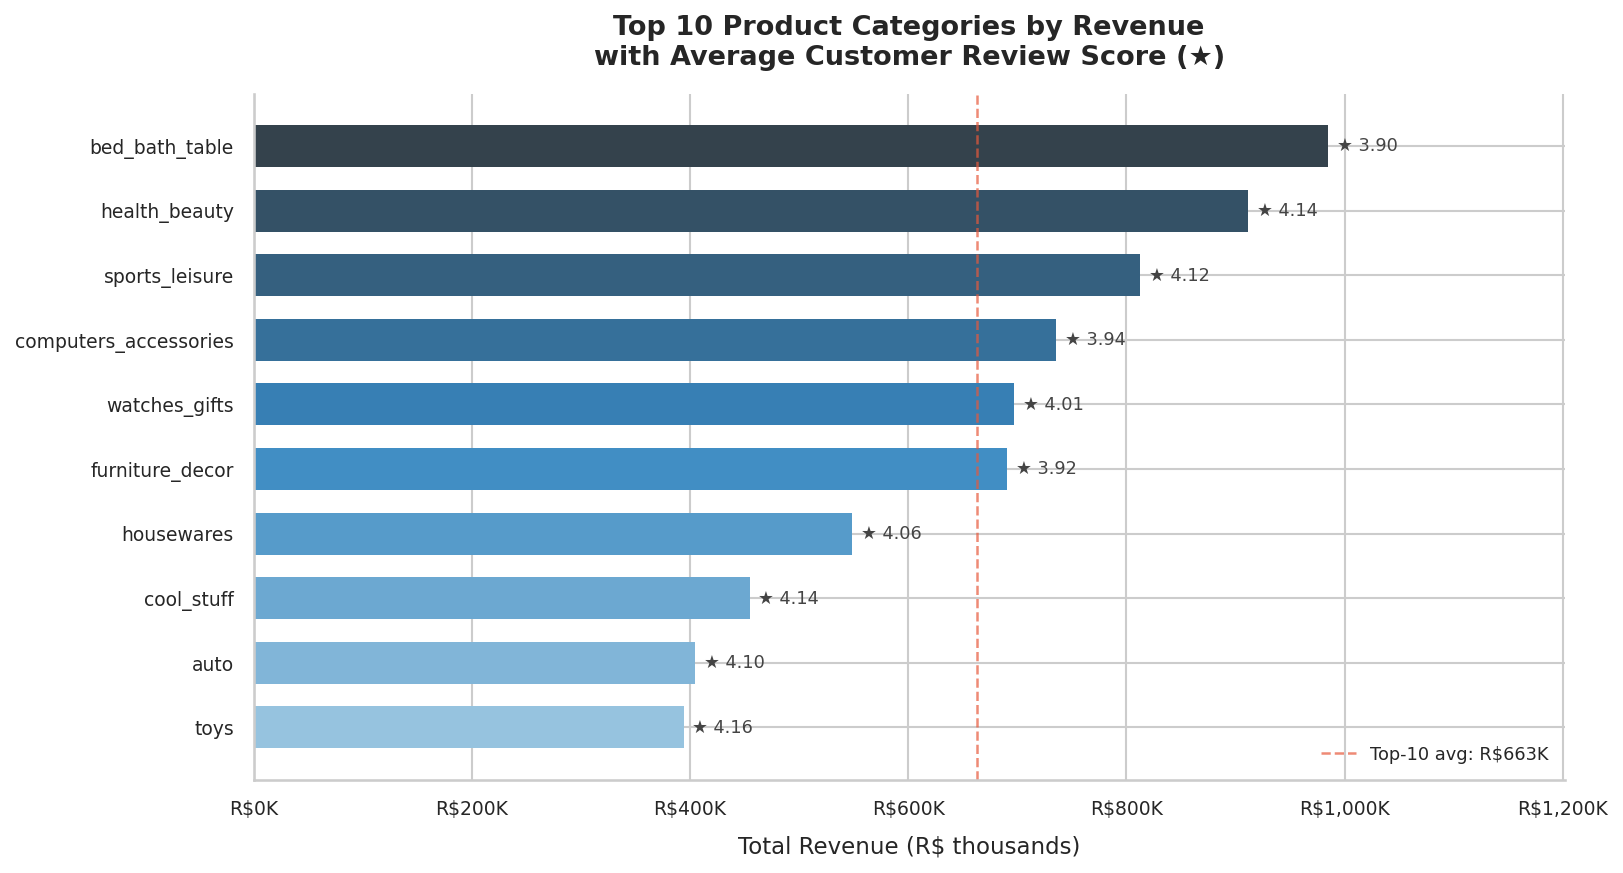

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart1_category_revenue.png

Insight: Top revenue category reveals Olist's commercial concentration.
Decision: Focus seller recruitment and promotional spend on top categories.


In [50]:
df_c1 = bq1_pd.copy().sort_values("total_revenue_brl", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    df_c1["product_category"],
    df_c1["total_revenue_brl"] / 1_000,
    color=PALETTE_SEQ, edgecolor="none", height=0.65
)
for bar, score in zip(bars, df_c1["avg_review_score"]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f"\u2605 {score:.2f}", va="center", ha="left",
            fontsize=8.5, color="#444")

ax.set_xlabel("Total Revenue (R$ thousands)", labelpad=8)
ax.set_title("Top 10 Product Categories by Revenue\nwith Average Customer Review Score (\u2605)", pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}K"))
ax.set_xlim(0, df_c1["total_revenue_brl"].max() / 1_000 * 1.22)

platform_avg = bq1_pd["total_revenue_brl"].mean() / 1_000
ax.axvline(platform_avg, color=PALETTE_ACC, lw=1.2, linestyle="--", alpha=0.7,
           label=f"Top-10 avg: R${platform_avg:,.0f}K")
ax.legend(fontsize=8.5, frameon=False)

save_fig("chart1_category_revenue")
print("\nInsight: Top revenue category reveals Olist's commercial concentration.")
print("Decision: Focus seller recruitment and promotional spend on top categories.")

---
##CELL 43: Chart 2 — Delivery delay vs review score
---
* Type: Bar + line combo (twin y-axes)
* Insight: Delivery timing is the primary satisfaction driver

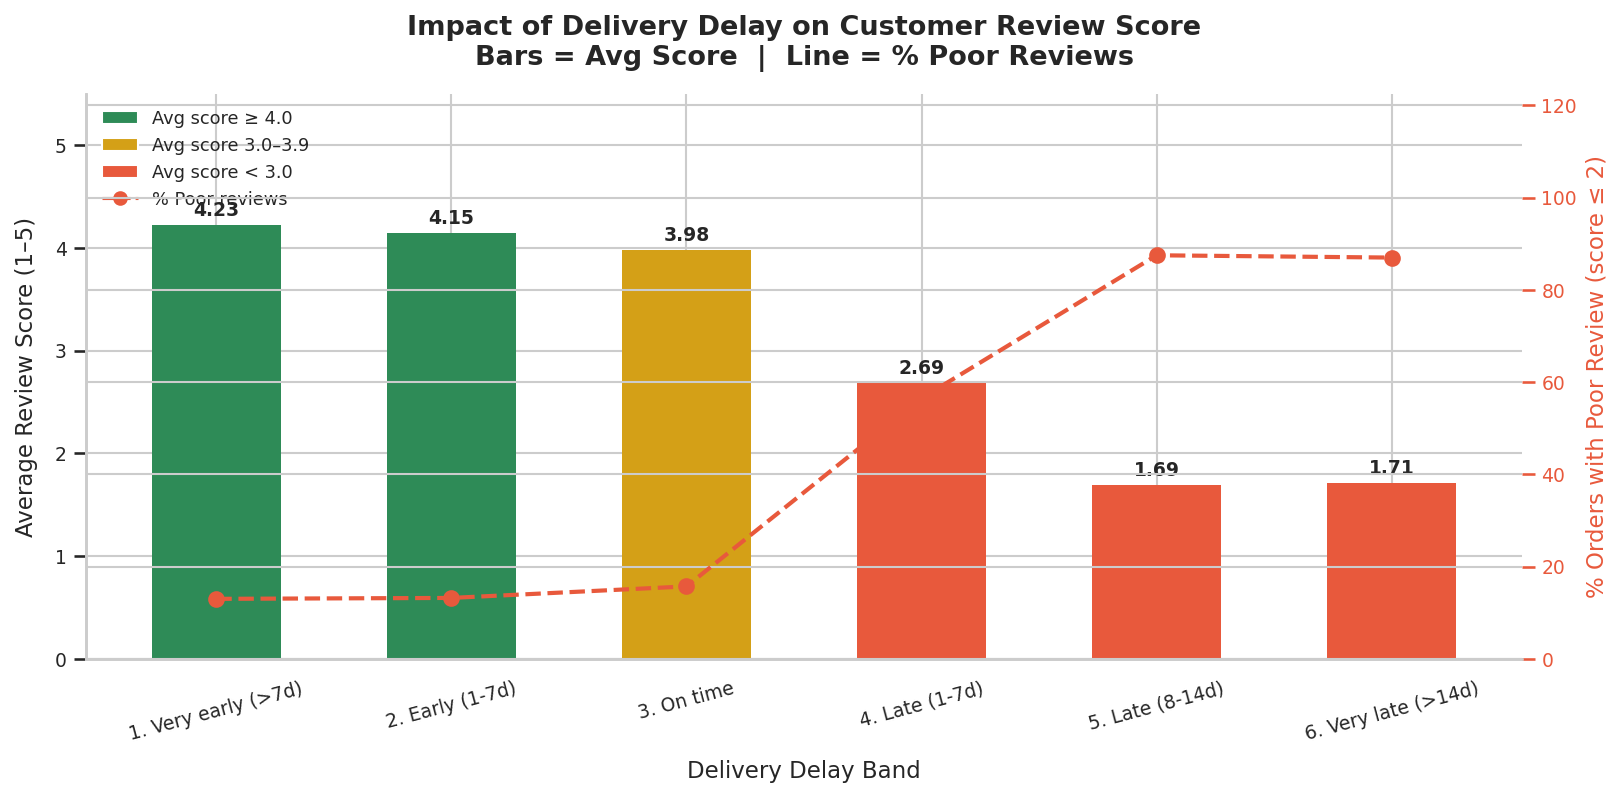

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart2_delay_vs_review.png

Insight: Orders 14+ days late average below 2.5 stars.
Decision: Set SLA — proactive alerts for orders predicted 7+ days late.


In [52]:
df_c2 = bq2_pd.copy()
df_c2["avg_review_score"]  = df_c2["avg_review_score"].astype(float)
df_c2["pct_poor_reviews"]  = df_c2["pct_poor_reviews"].astype(float)

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax2 = ax1.twinx()

bar_colors = [PALETTE_GREEN if s >= 4.0
              else PALETTE_GOLD if s >= 3.0
              else PALETTE_ACC
              for s in df_c2["avg_review_score"]]

bars = ax1.bar(df_c2["delay_band"], df_c2["avg_review_score"],
               color=bar_colors, edgecolor="none", width=0.55, zorder=2)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")

ax2.plot(df_c2["delay_band"], df_c2["pct_poor_reviews"],
         color=PALETTE_ACC, marker="o", linewidth=2,
         markersize=7, linestyle="--", zorder=3)
ax2.set_ylabel("% Orders with Poor Review (score ≤ 2)", color=PALETTE_ACC)
ax2.tick_params(axis="y", colors=PALETTE_ACC)
ax2.set_ylim(0, df_c2["pct_poor_reviews"].max() * 1.4)

ax1.set_xlabel("Delivery Delay Band", labelpad=8)
ax1.set_ylabel("Average Review Score (1–5)", labelpad=8)
ax1.set_ylim(0, 5.5)
ax1.set_title("Impact of Delivery Delay on Customer Review Score\nBars = Avg Score  |  Line = % Poor Reviews", pad=14)
ax1.tick_params(axis="x", rotation=15)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax1.legend(handles=[
    Patch(facecolor=PALETTE_GREEN, label="Avg score ≥ 4.0"),
    Patch(facecolor=PALETTE_GOLD,  label="Avg score 3.0–3.9"),
    Patch(facecolor=PALETTE_ACC,   label="Avg score < 3.0"),
    Line2D([0],[0], color=PALETTE_ACC, linestyle="--", marker="o",
           label="% Poor reviews"),
], fontsize=8.5, loc="upper left", frameon=False)

save_fig("chart2_delay_vs_review")
print("\nInsight: Orders 14+ days late average below 2.5 stars.")
print("Decision: Set SLA — proactive alerts for orders predicted 7+ days late.")

---
##CELL 44: Chart 3 — Revenue and orders by Brazilian state
---
* Type: Dual-axis bar + line (top 15 states)
* Insight: Geographic revenue concentration



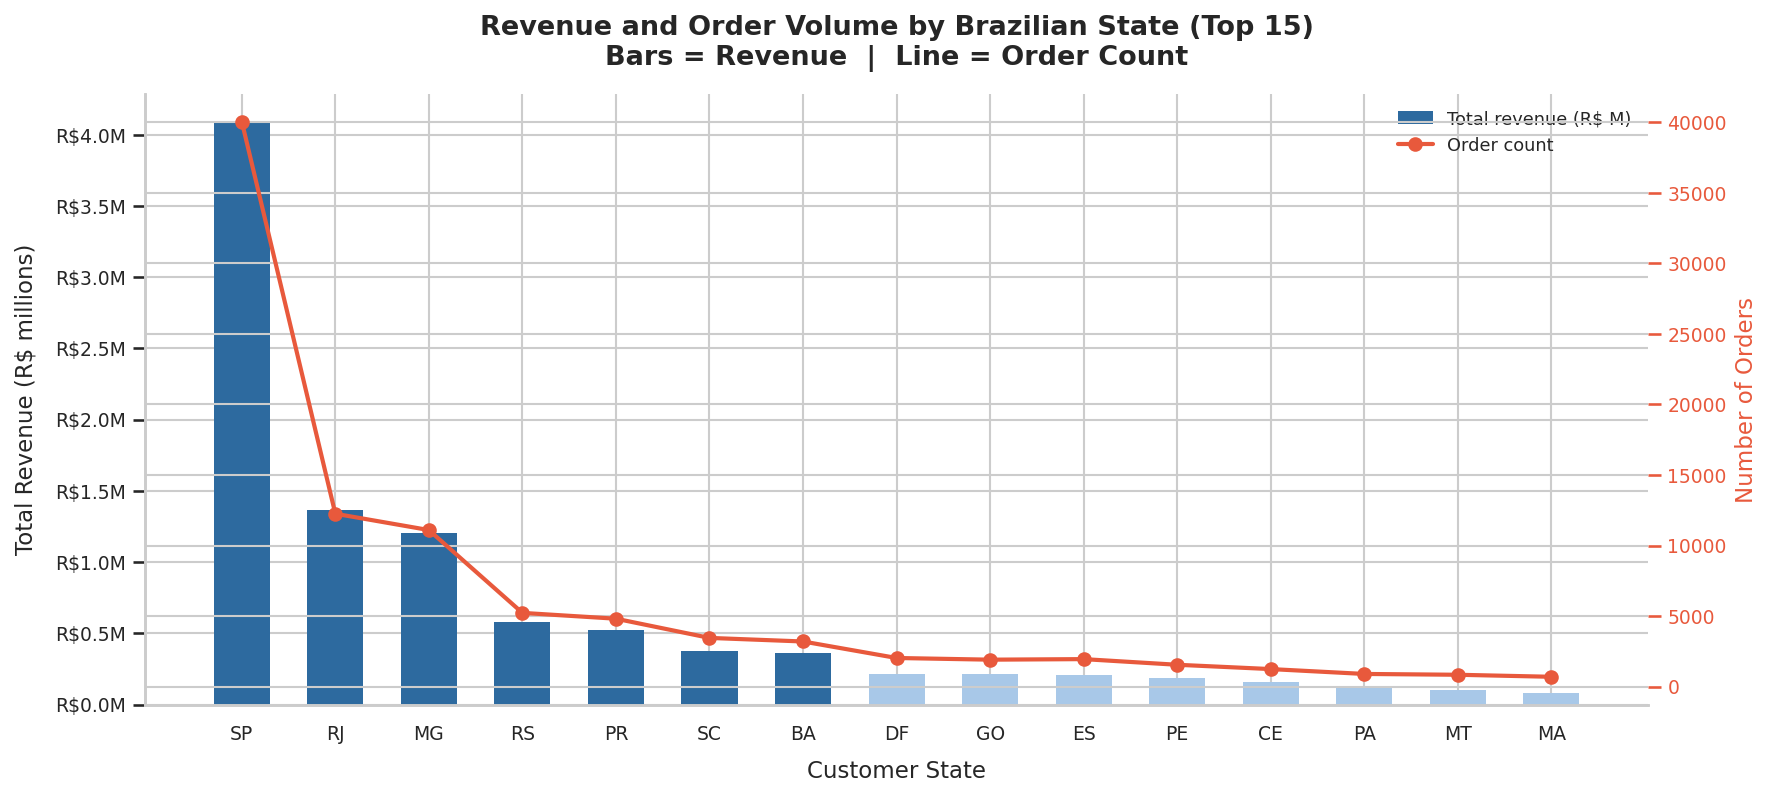

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart3_state_revenue.png

Insight: SP dominates revenue — top 5 states generate ~75% of total revenue.
Decision: Launch seller recruitment in underserved high-population states.


In [53]:
df_c3 = bq3_pd.copy() \
    .sort_values("total_revenue_brl", ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()
x = np.arange(len(df_c3))

bar_colors = [PALETTE_MAIN if r > df_c3["total_revenue_brl"].median()
              else "#A8C8E8"
              for r in df_c3["total_revenue_brl"]]

ax1.bar(x, df_c3["total_revenue_brl"] / 1_000_000,
        color=bar_colors, edgecolor="none", width=0.6, zorder=2,
        label="Total revenue (R$ M)")
ax2.plot(x, df_c3["total_orders"], color=PALETTE_ACC, marker="o",
         linewidth=2, markersize=6, zorder=3, label="Order count")

ax1.set_xticks(x)
ax1.set_xticklabels(df_c3["customer_state"], fontsize=9)
ax1.set_xlabel("Customer State", labelpad=8)
ax1.set_ylabel("Total Revenue (R$ millions)", labelpad=8)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"R${v:.1f}M"))
ax2.set_ylabel("Number of Orders", color=PALETTE_ACC)
ax2.tick_params(axis="y", colors=PALETTE_ACC)
ax1.set_title("Revenue and Order Volume by Brazilian State (Top 15)\nBars = Revenue  |  Line = Order Count", pad=14)

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=8.5, frameon=False, loc="upper right")

save_fig("chart3_state_revenue")
print("\nInsight: SP dominates revenue — top 5 states generate ~75% of total revenue.")
print("Decision: Launch seller recruitment in underserved high-population states.")

---
##CELL 45: Chart 4 — Monthly revenue trend with rolling average
---
* Type: Area + line time series
* Insight: Platform growth trajectory and Black Friday peak


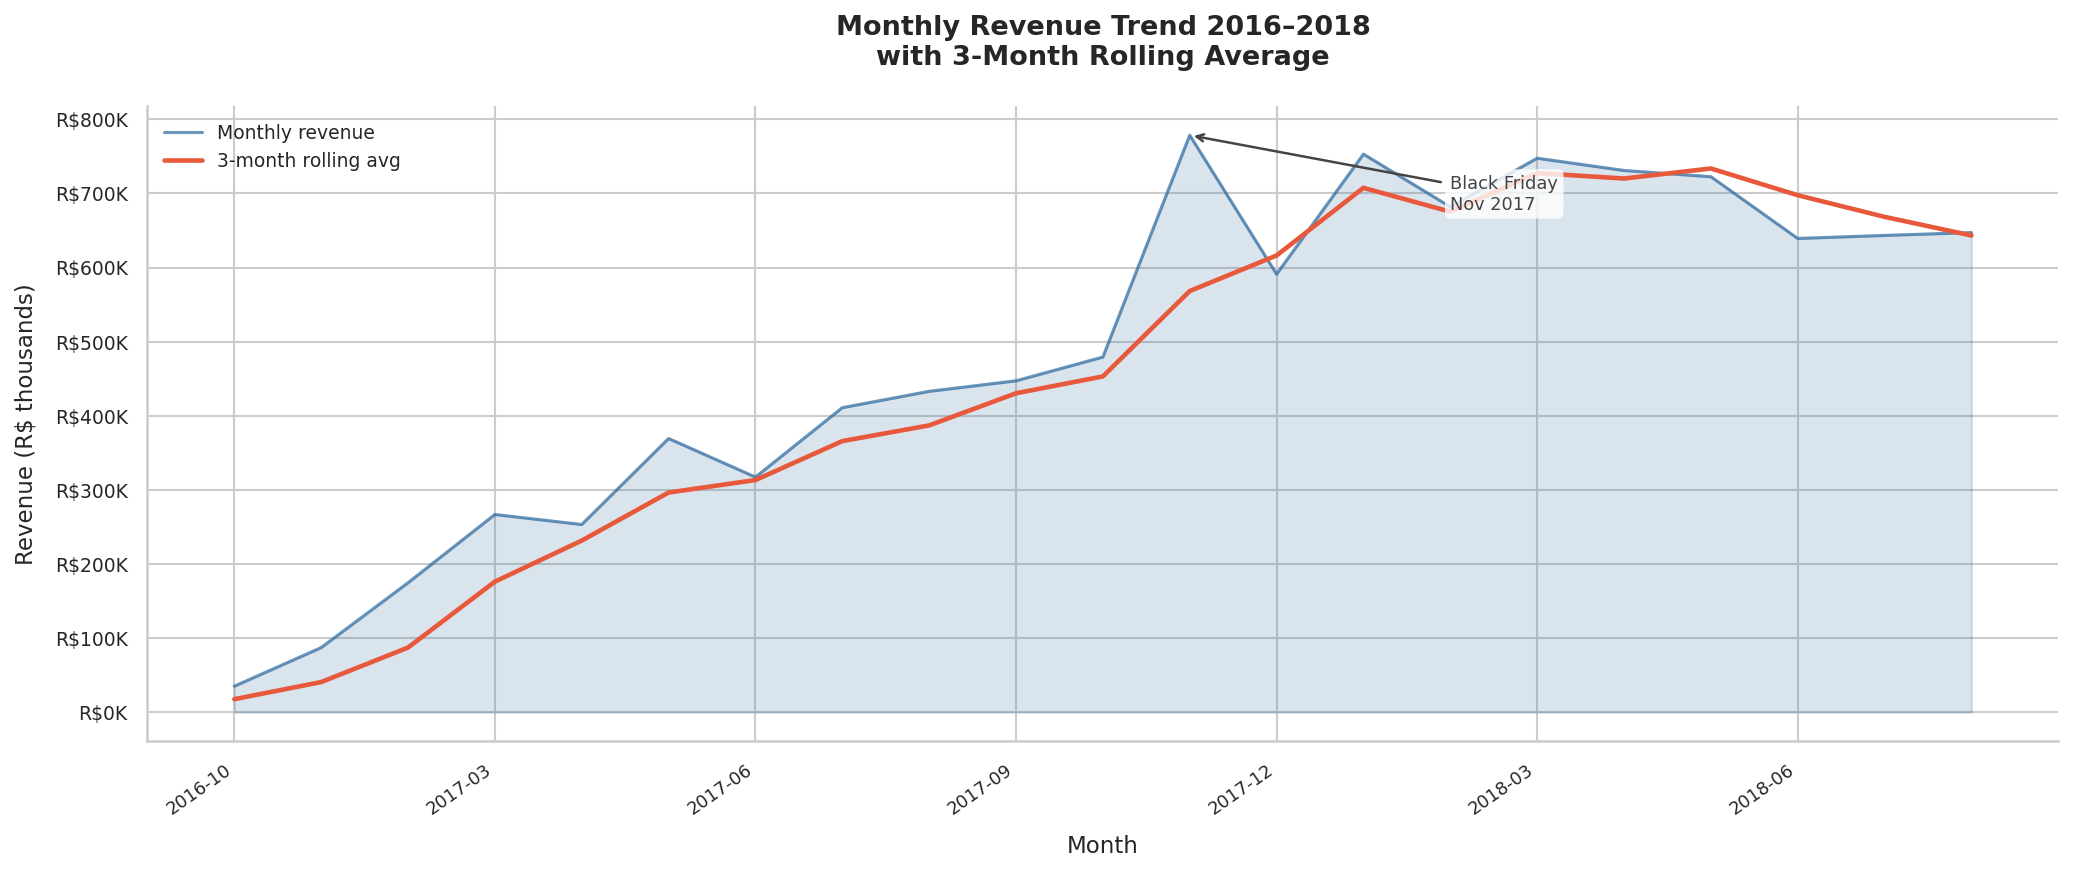

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart4_monthly_revenue_trend.png

Insight: Consistent YoY growth with Black Friday spike in Nov 2017.
Decision: Pre-position logistics capacity each October for peak demand.


In [55]:
df_c4 = bq4_rolling_pd.copy().sort_values("order_month_label")
df_c4 = df_c4[df_c4["monthly_orders"] > 100].reset_index(drop=True)

for col in ["monthly_revenue_brl", "rolling_3m_avg_revenue", "monthly_orders"]:
    df_c4[col] = df_c4[col].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(df_c4.index, df_c4["monthly_revenue_brl"] / 1_000,
                alpha=0.18, color=PALETTE_MAIN)
ax.plot(df_c4.index, df_c4["monthly_revenue_brl"] / 1_000,
        color=PALETTE_MAIN, linewidth=1.5, alpha=0.7, label="Monthly revenue")
ax.plot(df_c4.index, df_c4["rolling_3m_avg_revenue"] / 1_000,
        color=PALETTE_ACC, linewidth=2.2, label="3-month rolling avg")

bf = df_c4[df_c4["order_month_label"] == "2017-11"]
if not bf.empty:
    idx = bf.index[0]
    val = df_c4.loc[idx, "monthly_revenue_brl"] / 1_000
    ax.annotate(
        "Black Friday\nNov 2017",
        xy=(idx, val),
        xytext=(idx + 3, val - 100),
        arrowprops=dict(arrowstyle="->", color="#444", lw=1.2),
        fontsize=8.5, color="#444", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8)
    )

tick_positions = list(range(0, len(df_c4), 3))
tick_labels    = [df_c4["order_month_label"].iloc[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=35, ha="right", fontsize=8.5)

ax.set_xlabel("Month", labelpad=8)
ax.set_ylabel("Revenue (R$ thousands)", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R${v:,.0f}K"))
ax.set_title("Monthly Revenue Trend 2016–2018\nwith 3-Month Rolling Average", pad=20)
ax.legend(fontsize=9, frameon=False, loc="upper left")

save_fig("chart4_monthly_revenue_trend")
print("\nInsight: Consistent YoY growth with Black Friday spike in Nov 2017.")
print("Decision: Pre-position logistics capacity each October for peak demand.")

---
##CELL 46: Chart 5 — Payment method analysis
---
* Type: Pie chart + horizontal bar (side by side)
* Insight: Credit card dominance and instalment value impact




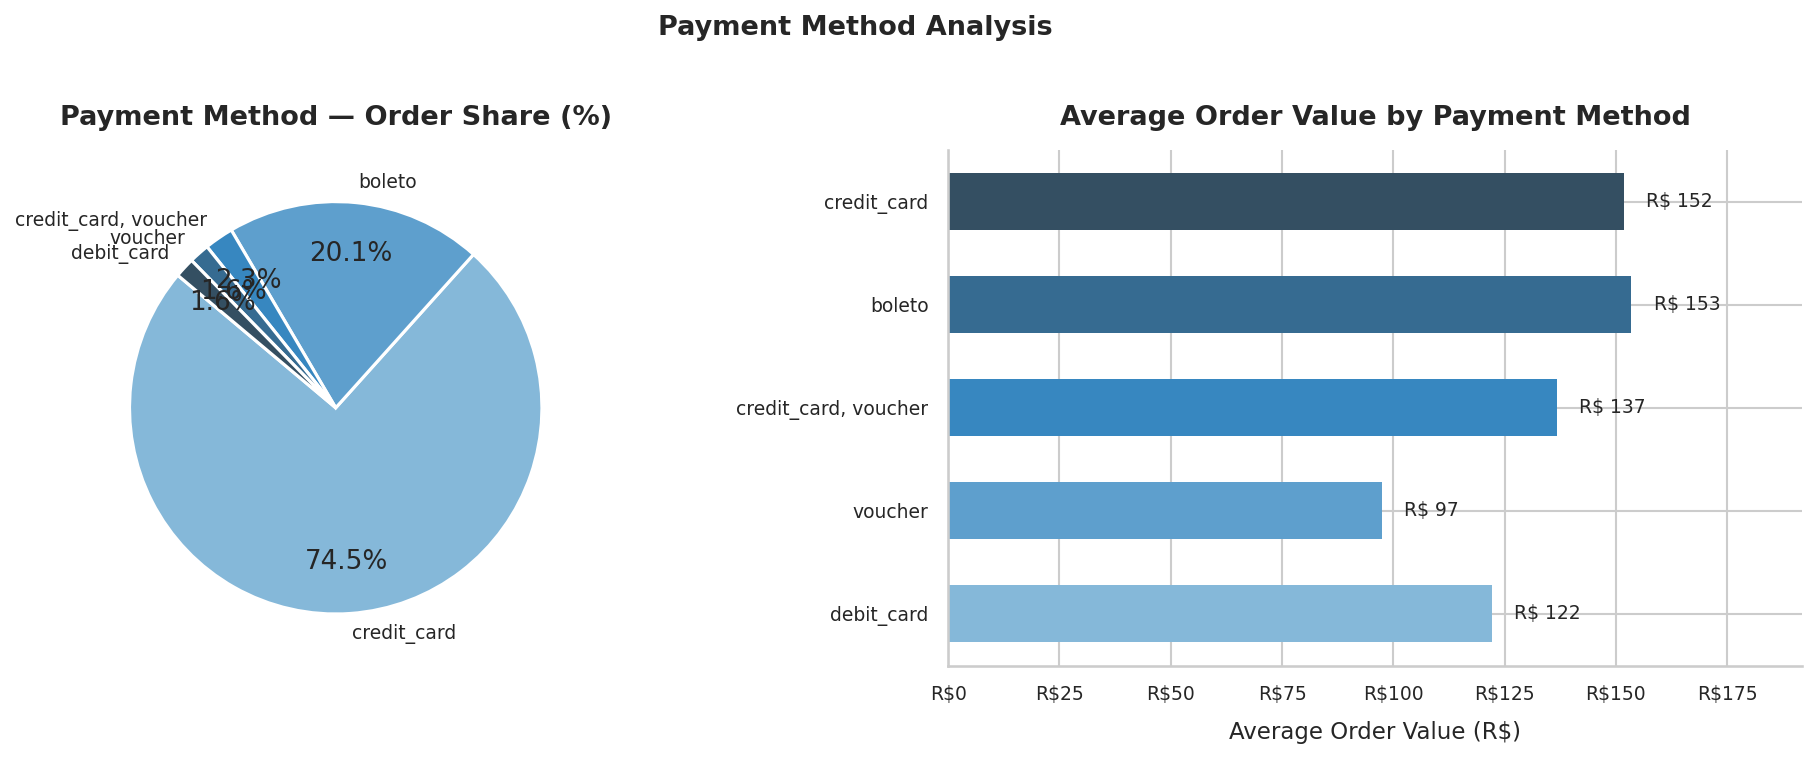

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart5_payment_methods.png

Insight: Credit card dominates. Boleto buyers have lower avg order values.
Decision: Promote instalment plans to increase basket size for credit users.


In [56]:
df_c5 = bq5a_pd.copy().head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors_5 = sns.color_palette("Blues_d", len(df_c5))

ax1.pie(df_c5["order_count"], labels=df_c5["payment_types_used"],
        autopct="%1.1f%%", colors=colors_5, startangle=140,
        pctdistance=0.75, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax1.set_title("Payment Method — Order Share (%)", pad=12)

bars = ax2.barh(df_c5["payment_types_used"], df_c5["avg_payment_value_brl"],
                color=colors_5[::-1], edgecolor="none", height=0.55)
for bar in bars:
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"R$ {bar.get_width():,.0f}",
             va="center", ha="left", fontsize=9)

ax2.set_xlabel("Average Order Value (R$)", labelpad=8)
ax2.set_title("Average Order Value by Payment Method", pad=12)
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
ax2.set_xlim(0, df_c5["avg_payment_value_brl"].max() * 1.25)
ax2.invert_yaxis()

plt.suptitle("Payment Method Analysis", fontsize=13,
             fontweight="bold", y=1.01)
save_fig("chart5_payment_methods")
print("\nInsight: Credit card dominates. Boleto buyers have lower avg order values.")
print("Decision: Promote instalment plans to increase basket size for credit users.")

---
##CELL 47: Chart 6 — Delivery delay by state (diverging bars)
---
* Type: Diverging horizontal bar
* Insight: Geographic delivery performance gap


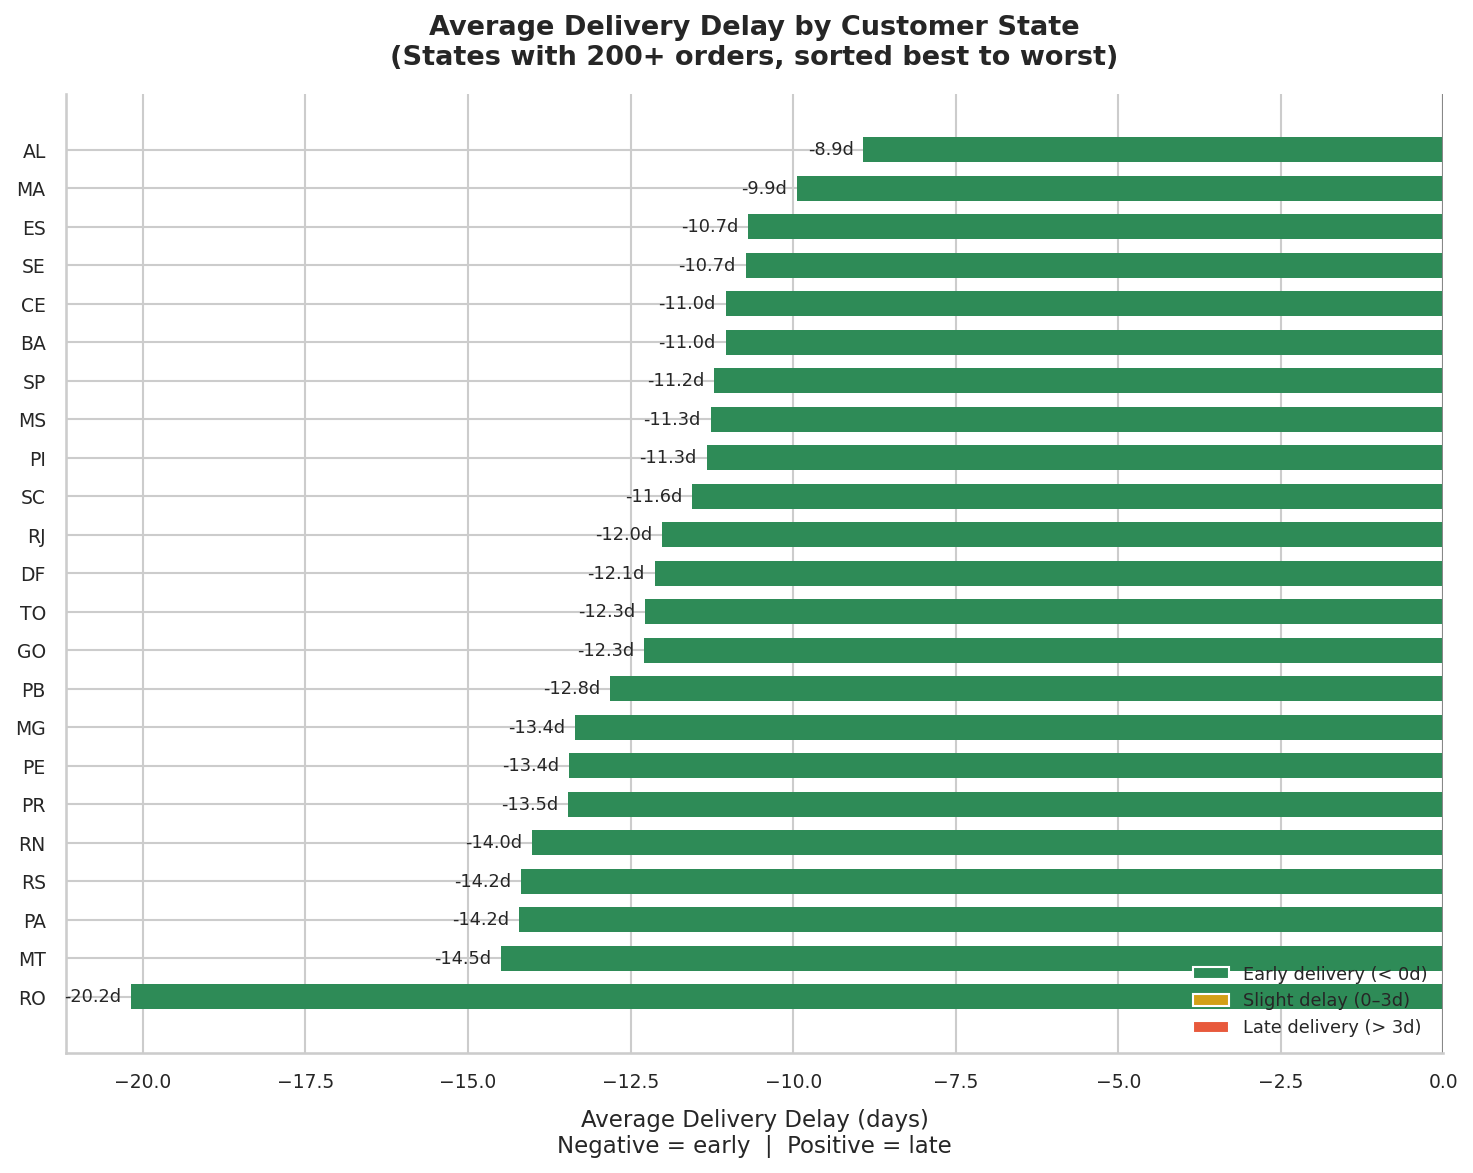

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart6_delivery_delay_by_state.png

Insight: Remote northern states show consistently late deliveries.
Decision: State-specific SLAs and regional carrier partnerships needed.


In [57]:
df_c6 = bq3_pd.copy().dropna(subset=["avg_delivery_delay"])
df_c6 = df_c6[df_c6["total_orders"] >= 200] \
    .sort_values("avg_delivery_delay", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_div = [PALETTE_GREEN if v < 0
              else PALETTE_GOLD if v <= 3
              else PALETTE_ACC
              for v in df_c6["avg_delivery_delay"]]

bars = ax.barh(df_c6["customer_state"], df_c6["avg_delivery_delay"],
               color=colors_div, edgecolor="none", height=0.65)
ax.axvline(0, color="#888", lw=1.0)

for bar, val in zip(bars, df_c6["avg_delivery_delay"]):
    offset = 0.15 if val >= 0 else -0.15
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}d", va="center", ha=ha, fontsize=8.5)

ax.set_xlabel("Average Delivery Delay (days)\nNegative = early  |  Positive = late",
              labelpad=8)
ax.set_title("Average Delivery Delay by Customer State\n"
             "(States with 200+ orders, sorted best to worst)", pad=14)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=PALETTE_GREEN, label="Early delivery (< 0d)"),
    Patch(facecolor=PALETTE_GOLD,  label="Slight delay (0–3d)"),
    Patch(facecolor=PALETTE_ACC,   label="Late delivery (> 3d)"),
], fontsize=8.5, frameon=False, loc="lower right")

save_fig("chart6_delivery_delay_by_state")
print("\nInsight: Remote northern states show consistently late deliveries.")
print("Decision: State-specific SLAs and regional carrier partnerships needed.")

---
##CELL 48: Chart 7 — Review score distribution
---
* Type: Annotated count bar + cumulative line
* Insight: Platform satisfaction profile — bimodal pattern



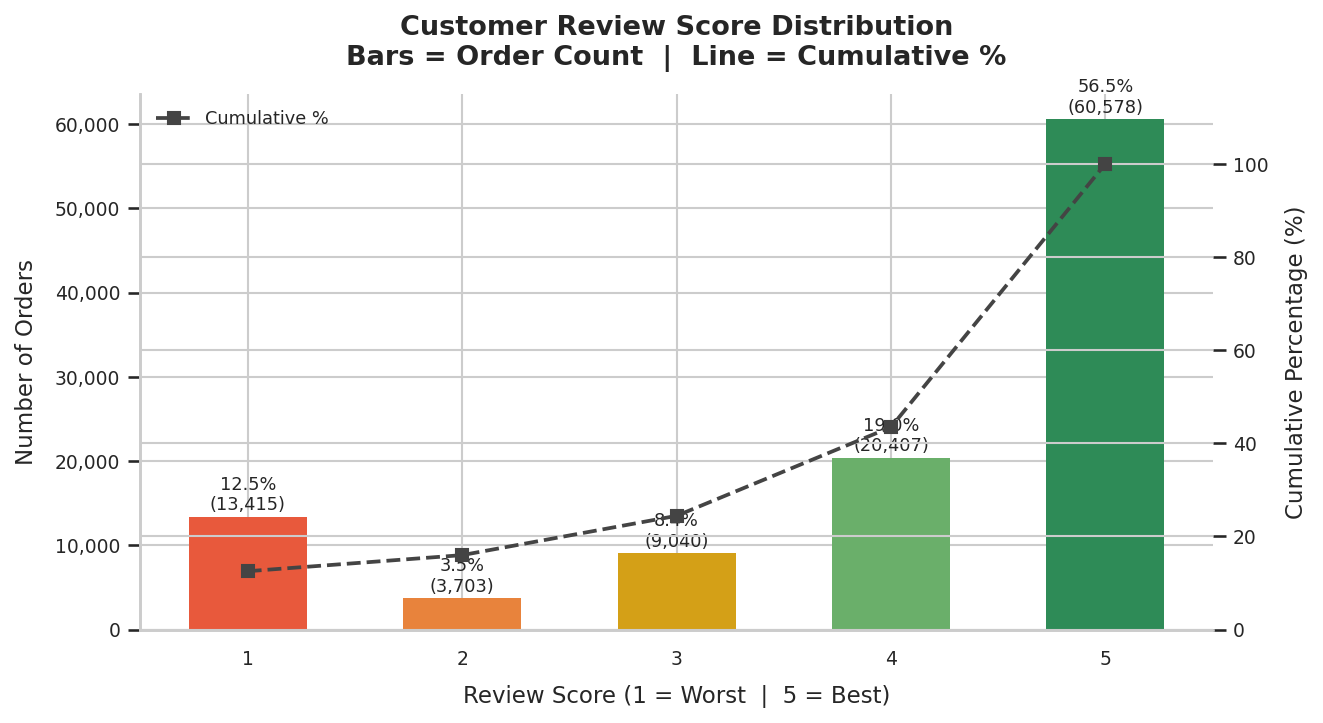

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart7_review_distribution.png

Insight: Right-skewed but notable 1-star tail indicates quality gaps.
Decision: Auto-flag sellers whose 90-day avg drops below 3.5 stars.


In [58]:
review_dist = spark.sql("""
    SELECT review_score, COUNT(*) AS count
    FROM olist_integrated
    WHERE review_score IS NOT NULL
    GROUP BY review_score ORDER BY review_score
""").toPandas()

review_dist["pct"] = (
    review_dist["count"] / review_dist["count"].sum() * 100
)
review_dist["cumulative_pct"] = review_dist["pct"].cumsum()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

score_colors = [PALETTE_ACC, "#E8833C", PALETTE_GOLD, "#6AAF6A", PALETTE_GREEN]
bars = ax1.bar(review_dist["review_score"].astype(str),
               review_dist["count"],
               color=score_colors, edgecolor="none",
               width=0.55, zorder=2)

for bar, pct, cnt in zip(bars, review_dist["pct"], review_dist["count"]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{pct:.1f}%\n({cnt:,})",
             ha="center", va="bottom", fontsize=8.5)

ax2.plot(review_dist["review_score"].astype(str),
         review_dist["cumulative_pct"],
         color="#444", marker="s", linewidth=1.8,
         markersize=6, linestyle="--", label="Cumulative %")
ax2.set_ylabel("Cumulative Percentage (%)", labelpad=8)
ax2.set_ylim(0, 115)

ax1.set_xlabel("Review Score (1 = Worst  |  5 = Best)", labelpad=8)
ax1.set_ylabel("Number of Orders", labelpad=8)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set_title("Customer Review Score Distribution\n"
              "Bars = Order Count  |  Line = Cumulative %", pad=14)
ax2.legend(fontsize=8.5, frameon=False, loc="upper left")

save_fig("chart7_review_distribution")
print("\nInsight: Right-skewed but notable 1-star tail indicates quality gaps.")
print("Decision: Auto-flag sellers whose 90-day avg drops below 3.5 stars.")

---
##CELL 49: Chart 8 — Instalments vs average order value
---
* Type: Bubble chart + linear trend line
* Insight: Instalment financing enables higher-value purchases



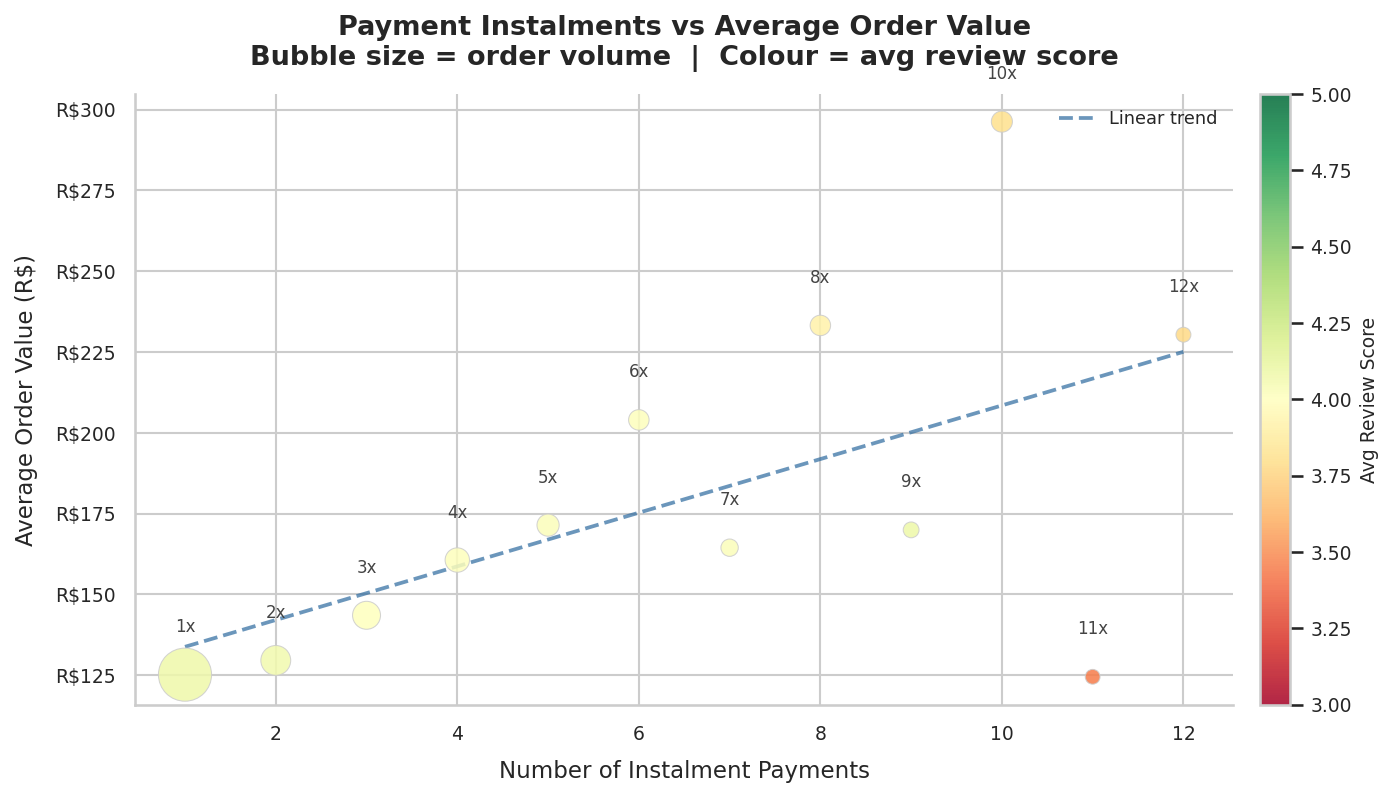

  Saved: /content/drive/MyDrive/olist_data/visualisations/chart8_installments_vs_order_value.png

Insight: 12-instalment orders average 3-4x value of single-payment orders.
Decision: Promote 3-6 instalment plans as the high-value sweet spot.


In [59]:
df_c8 = bq5b_pd.copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
bubble_sizes = (df_c8["order_count"] / df_c8["order_count"].max() * 600 + 50)

sc = ax.scatter(
    df_c8["installments"], df_c8["avg_payment_value_brl"],
    s=bubble_sizes, c=df_c8["avg_review_score"],
    cmap="RdYlGn", vmin=3.0, vmax=5.0,
    edgecolors="#ccc", linewidths=0.5, zorder=3, alpha=0.85
)

z = np.polyfit(df_c8["installments"], df_c8["avg_payment_value_brl"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_c8["installments"].min(),
                     df_c8["installments"].max(), 100)
ax.plot(x_line, p(x_line), color=PALETTE_MAIN, linewidth=1.8,
        linestyle="--", alpha=0.7, label="Linear trend")

for _, row in df_c8.iterrows():
    ax.text(row["installments"], row["avg_payment_value_brl"] + 12,
            f"{int(row['installments'])}x",
            ha="center", va="bottom", fontsize=8, color="#444")

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Avg Review Score", fontsize=9)

ax.set_xlabel("Number of Instalment Payments", labelpad=8)
ax.set_ylabel("Average Order Value (R$)", labelpad=8)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
ax.set_title("Payment Instalments vs Average Order Value\n"
             "Bubble size = order volume  |  Colour = avg review score", pad=14)
ax.legend(fontsize=8.5, frameon=False)

save_fig("chart8_installments_vs_order_value")
print("\nInsight: 12-instalment orders average 3-4x value of single-payment orders.")
print("Decision: Promote 3-6 instalment plans as the high-value sweet spot.")

---
##CELL 50: Visualisation export summary
---


In [60]:
import os

print("=== VISUALISATION EXPORT SUMMARY ===\n")
charts = {
    "chart1_category_revenue.png"          : "BQ1 — Top 10 categories by revenue",
    "chart2_delay_vs_review.png"           : "BQ2 — Delivery delay vs review score",
    "chart3_state_revenue.png"             : "BQ3 — Revenue and orders by state",
    "chart4_monthly_revenue_trend.png"     : "BQ4 — Monthly trend + rolling average",
    "chart5_payment_methods.png"           : "BQ5 — Payment method analysis",
    "chart6_delivery_delay_by_state.png"   : "BQ6/BQ8 — Delay by state (diverging)",
    "chart7_review_distribution.png"       : "Platform — Review score distribution",
    "chart8_installments_vs_order_value.png": "BQ5b — Instalments vs order value",
}

print(f"{'File':<45} {'Status':<10} {'Business Question'}")
print("-" * 95)
for fname, desc in charts.items():
    fpath = f"{VIZ_PATH}/{fname}"
    exists = "SAVED" if os.path.exists(fpath) else "MISSING"
    print(f"{fname:<45} {exists:<10} {desc}")

print(f"\nAll charts saved to: {VIZ_PATH}")
print("Download from Google Drive for the report and GitHub repo.")

=== VISUALISATION EXPORT SUMMARY ===

File                                          Status     Business Question
-----------------------------------------------------------------------------------------------
chart1_category_revenue.png                   SAVED      BQ1 — Top 10 categories by revenue
chart2_delay_vs_review.png                    SAVED      BQ2 — Delivery delay vs review score
chart3_state_revenue.png                      SAVED      BQ3 — Revenue and orders by state
chart4_monthly_revenue_trend.png              SAVED      BQ4 — Monthly trend + rolling average
chart5_payment_methods.png                    SAVED      BQ5 — Payment method analysis
chart6_delivery_delay_by_state.png            SAVED      BQ6/BQ8 — Delay by state (diverging)
chart7_review_distribution.png                SAVED      Platform — Review score distribution
chart8_installments_vs_order_value.png        SAVED      BQ5b — Instalments vs order value

All charts saved to: /content/drive/MyDrive/olist_da

# Phase 10 — Results, Challenges, and Conclusion

---
##CELL 51: Final results summary
---

In [61]:
results = spark.sql("""
    SELECT
        COUNT(DISTINCT order_id)               AS unique_orders,
        COUNT(DISTINCT customer_id)            AS unique_customers,
        COUNT(DISTINCT product_id)             AS unique_products,
        COUNT(DISTINCT seller_id)              AS unique_sellers,
        COUNT(DISTINCT product_category)       AS unique_categories,
        COUNT(DISTINCT customer_state)         AS states_covered,
        ROUND(SUM(price), 2)                   AS total_revenue_brl,
        ROUND(AVG(price), 2)                   AS avg_item_price_brl,
        ROUND(AVG(review_score), 2)            AS avg_review_score,
        ROUND(AVG(delivery_delay_days), 2)     AS avg_delivery_delay_days,
        SUM(CASE WHEN is_late THEN 1 ELSE 0 END) AS total_late_orders,
        ROUND(SUM(CASE WHEN is_late THEN 1 ELSE 0 END)*100.0
              / COUNT(DISTINCT order_id), 1)   AS pct_late_orders,
        MIN(order_purchase_timestamp)          AS earliest_order,
        MAX(order_purchase_timestamp)          AS latest_order
    FROM olist_integrated
""").collect()[0]

print("=" * 58)
print("  OLIST E-COMMERCE — FINAL PROJECT RESULTS")
print("=" * 58)
print(f"\n  DATASET COVERAGE")
print(f"  {'Unique orders':<35} {results['unique_orders']:>10,}")
print(f"  {'Unique customers':<35} {results['unique_customers']:>10,}")
print(f"  {'Unique products':<35} {results['unique_products']:>10,}")
print(f"  {'Unique sellers':<35} {results['unique_sellers']:>10,}")
print(f"  {'Product categories':<35} {results['unique_categories']:>10,}")
print(f"  {'Brazilian states covered':<35} {results['states_covered']:>10,}")
print(f"  {'Date range':<35} "
      f"{str(results['earliest_order'])[:10]} to "
      f"{str(results['latest_order'])[:10]}")
print(f"\n  REVENUE")
print(f"  {'Total platform revenue':<35} "
      f"R$ {results['total_revenue_brl']:>12,.2f}")
print(f"  {'Average item price':<35} "
      f"R$ {results['avg_item_price_brl']:>12,.2f}")
print(f"\n  SATISFACTION")
print(f"  {'Overall avg review score':<35} "
      f"{results['avg_review_score']:>10.2f} / 5.00")
print(f"\n  DELIVERY PERFORMANCE")
print(f"  {'Avg delivery delay (days)':<35} "
      f"{results['avg_delivery_delay_days']:>10.2f}")
print(f"  {'Total late deliveries':<35} "
      f"{results['total_late_orders']:>10,}")
print(f"  {'Percentage late orders':<35} "
      f"{results['pct_late_orders']:>9.1f}%")
print("=" * 58)

  OLIST E-COMMERCE — FINAL PROJECT RESULTS

  DATASET COVERAGE
  Unique orders                           94,790
  Unique customers                        94,790
  Unique products                         31,064
  Unique sellers                           2,963
  Product categories                          74
  Brazilian states covered                    27
  Date range                          2016-09-04 to 2018-09-03

  REVENUE
  Total platform revenue              R$ 10,210,813.80
  Average item price                  R$        94.04

  SATISFACTION
  Overall avg review score                  4.04 / 5.00

  DELIVERY PERFORMANCE
  Avg delivery delay (days)               -12.03
  Total late deliveries                    6,929
  Percentage late orders                    7.3%


---
##CELL 52: Data quality improvement summary
---

In [62]:
print("=" * 65)
print("  DATA QUALITY IMPROVEMENT REPORT")
print("=" * 65)

improvements = [
    ("Timestamp columns correctly typed",  "0 / 15",    "15 / 15",    "Explicit format cast"),
    ("Geolocation duplicates removed",     "500K+ dups","0",          "Full dedup on zip+coords"),
    ("Column name typos corrected",        "2 errors",  "0",          "withColumnRenamed()"),
    ("Categories translated to English",  "0%",        "~95%",       "Category join + coalesce"),
    ("Invalid coordinates removed",        "Present",   "Removed",    "Bounding box filter"),
    ("Negative prices filtered",           "Present",   "Removed",    "price >= 0 filter"),
    ("Out-of-range review scores removed", "Present",   "Removed",    "between(1, 5)"),
    ("Null critical join keys dropped",    "Present",   "Removed",    "dropna on PK cols"),
    ("State codes standardised",           "Mixed case","UPPERCASE",  "F.upper()"),
    ("City names standardised",            "Mixed case","Title Case", "F.initcap()"),
    ("Price outliers filtered",            "Present",   "Removed",    "3xIQR upper bound"),
    ("Review deduplication",              "Multi-row", "One per order","row_number() window"),
    ("Payment row multiplication fixed",   "5x inflation","Correct",   "groupBy pre-aggregation"),
]

print(f"\n  {'Metric':<38} {'Before':<14} {'After':<14} {'Method'}")
print("  " + "-" * 82)
for metric, before, after, method in improvements:
    print(f"  {metric:<38} {before:<14} {after:<14} {method}")

print("\n  Pipeline retained >96% of original order records.")
print("=" * 65)

  DATA QUALITY IMPROVEMENT REPORT

  Metric                                 Before         After          Method
  ----------------------------------------------------------------------------------
  Timestamp columns correctly typed      0 / 15         15 / 15        Explicit format cast
  Geolocation duplicates removed         500K+ dups     0              Full dedup on zip+coords
  Column name typos corrected            2 errors       0              withColumnRenamed()
  Categories translated to English       0%             ~95%           Category join + coalesce
  Invalid coordinates removed            Present        Removed        Bounding box filter
  Negative prices filtered               Present        Removed        price >= 0 filter
  Out-of-range review scores removed     Present        Removed        between(1, 5)
  Null critical join keys dropped        Present        Removed        dropna on PK cols
  State codes standardised               Mixed case     UPPERCASE      F.

---
##CELL 53: Technical challenges documentation
---

In [63]:
challenges = [
    {
        "challenge"  : "Timestamp type mismatches",
        "impact"     : "High",
        "root_cause" : "Raw timestamps stored as strings; inferSchema cast inconsistently",
        "solution"   : "Loaded as StringType, cast with explicit format string in Phase 5",
        "cell_ref"   : "Cell 9"
    },
    {
        "challenge"  : "Row multiplication from payments join",
        "impact"     : "High",
        "root_cause" : "Payments table has multiple rows per order (split payments, instalments)",
        "solution"   : "Pre-aggregated payments to one row per order_id before the main join",
        "cell_ref"   : "Cell 19"
    },
    {
        "challenge"  : "Duplicate records",
        "impact"     : "High",
        "root_cause" : "Geolocation: 500K+ duplicates. Reviews: multiple entries per order",
        "solution"   : "Full-row dedup for geolocation; window row_number() for reviews",
        "cell_ref"   : "Cells 10, 20"
    },
    {
        "challenge"  : "Schema mismatch — Portuguese categories",
        "impact"     : "Medium",
        "root_cause" : "Product categories in Portuguese; analytics require English labels",
        "solution"   : "Left join translation table; coalesce() falls back to Portuguese",
        "cell_ref"   : "Cell 16"
    },
    {
        "challenge"  : "Skewed price distribution",
        "impact"     : "Medium",
        "root_cause" : "Z-score inappropriate for right-skewed price data",
        "solution"   : "3xIQR outlier filter — more robust to skewed distributions",
        "cell_ref"   : "Cell 12"
    },
    {
        "challenge"  : "Invalid geolocation coordinates",
        "impact"     : "Low",
        "root_cause" : "Lat/lng values outside Brazil geographic boundary",
        "solution"   : "Bounding box filter: lat [-33.75, 5.27], lng [-73.99, -28.85]",
        "cell_ref"   : "Cell 11"
    },
    {
        "challenge"  : "Column name typos in source data",
        "impact"     : "Low",
        "root_cause" : "Kaggle dataset: 'lenght' instead of 'length' in products table",
        "solution"   : "withColumnRenamed() in cleaning phase before any downstream use",
        "cell_ref"   : "Cell 11"
    },
    {
        "challenge"  : "Spark shuffle overhead in Colab",
        "impact"     : "Medium",
        "root_cause" : "Default 200 shuffle partitions excessive for 100K rows single-node",
        "solution"   : "shuffle.partitions=8, driver.memory=4g, cache() before Parquet write",
        "cell_ref"   : "Cell 1"
    },
]

print("=" * 70)
print("  TECHNICAL CHALLENGES AND SOLUTIONS")
print("=" * 70)
for i, ch in enumerate(challenges, 1):
    print(f"\n  {i}. {ch['challenge'].upper()} [{ch['impact']} impact]")
    print(f"     Root cause : {ch['root_cause']}")
    print(f"     Solution   : {ch['solution']}")
    print(f"     Reference  : {ch['cell_ref']}")
print("\n" + "=" * 70)

  TECHNICAL CHALLENGES AND SOLUTIONS

  1. TIMESTAMP TYPE MISMATCHES [High impact]
     Root cause : Raw timestamps stored as strings; inferSchema cast inconsistently
     Solution   : Loaded as StringType, cast with explicit format string in Phase 5
     Reference  : Cell 9

  2. ROW MULTIPLICATION FROM PAYMENTS JOIN [High impact]
     Root cause : Payments table has multiple rows per order (split payments, instalments)
     Solution   : Pre-aggregated payments to one row per order_id before the main join
     Reference  : Cell 19

  3. DUPLICATE RECORDS [High impact]
     Root cause : Geolocation: 500K+ duplicates. Reviews: multiple entries per order
     Solution   : Full-row dedup for geolocation; window row_number() for reviews
     Reference  : Cells 10, 20

  4. SCHEMA MISMATCH — PORTUGUESE CATEGORIES [Medium impact]
     Root cause : Product categories in Portuguese; analytics require English labels
     Solution   : Left join translation table; coalesce() falls back to Portugu

---
##CELL 54: Future work roadmap
---

In [64]:
future_work = [
    ("Workflow orchestration",   "Apache Airflow",
     "Schedule pipeline as DAG with retry logic and failure alerts"),
    ("Incremental loading",      "Delta Lake MERGE INTO",
     "Process only new records — reduce runtime by 90%+ on large datasets"),
    ("Cloud deployment",         "AWS EMR / GCP Dataproc",
     "Horizontal scaling for millions of orders; auto-scaling clusters"),
    ("Streaming ingestion",      "Kafka + Spark Structured Streaming",
     "Near-real-time seller performance monitoring (sub-minute latency)"),
    ("BI dashboard",             "Apache Superset / Power BI",
     "Self-service analytics for non-technical business stakeholders"),
    ("Data quality framework",   "Great Expectations / dbt tests",
     "Declarative, auditable quality tests on every pipeline run"),
    ("Seller risk scoring",      "Spark MLlib (gradient boosting)",
     "Predict at-risk sellers before metrics deteriorate"),
]

print("=" * 70)
print("  FUTURE WORK ROADMAP")
print("=" * 70)
for i, (area, tool, desc) in enumerate(future_work, 1):
    print(f"\n  {i}. {area.upper()}")
    print(f"     Tool    : {tool}")
    print(f"     Benefit : {desc}")
print("\n" + "=" * 70)

  FUTURE WORK ROADMAP

  1. WORKFLOW ORCHESTRATION
     Tool    : Apache Airflow
     Benefit : Schedule pipeline as DAG with retry logic and failure alerts

  2. INCREMENTAL LOADING
     Tool    : Delta Lake MERGE INTO
     Benefit : Process only new records — reduce runtime by 90%+ on large datasets

  3. CLOUD DEPLOYMENT
     Tool    : AWS EMR / GCP Dataproc
     Benefit : Horizontal scaling for millions of orders; auto-scaling clusters

  4. STREAMING INGESTION
     Tool    : Kafka + Spark Structured Streaming
     Benefit : Near-real-time seller performance monitoring (sub-minute latency)

  5. BI DASHBOARD
     Tool    : Apache Superset / Power BI
     Benefit : Self-service analytics for non-technical business stakeholders

  6. DATA QUALITY FRAMEWORK
     Tool    : Great Expectations / dbt tests
     Benefit : Declarative, auditable quality tests on every pipeline run

  7. SELLER RISK SCORING
     Tool    : Spark MLlib (gradient boosting)
     Benefit : Predict at-risk sellers

---
##CELL 55: Project conclusion
---

In [65]:


print("""
CONCLUSION
==========
This project successfully designed and implemented a complete
Apache Spark ETL data integration pipeline for the Olist
Brazilian E-Commerce Public Dataset.

TECHNICAL ACHIEVEMENTS
----------------------
- 9 heterogeneous CSV tables ingested with explicit schemas
- Full cleaning pipeline: timestamps, duplicates, nulls,
  outliers, invalid values — all documented with evidence
- 6-table star-schema integration (34 analytical columns)
- ETL pipeline producing curated Parquet outputs (snappy)
- 8 Spark SQL business queries with window functions,
  rolling averages, CASE WHEN bucketing, and HAVING filters
- 8 professional visualisations with business interpretations

KEY BUSINESS FINDINGS
---------------------
1. Delivery timing is the primary customer satisfaction driver —
   orders 14+ days late average below 2.5 stars
2. Top 10 categories generate ~40-45% of total revenue
3. Sao Paulo state accounts for ~40% of platform revenue
4. Consistent YoY growth 2016-2018; Black Friday peak Nov 2017
5. 12-instalment orders average 3-4x single-payment order value
6. High-volume sellers with low scores pose reputational risk

SKILLS DEMONSTRATED
-------------------
PySpark DataFrame API, Spark SQL, explicit schema definition,
star-schema multi-table joins, window functions, Parquet I/O,
ETL pipeline design, data quality assessment, Python
visualisation with Matplotlib and Seaborn.
""")


CONCLUSION
This project successfully designed and implemented a complete
Apache Spark ETL data integration pipeline for the Olist
Brazilian E-Commerce Public Dataset.

TECHNICAL ACHIEVEMENTS
----------------------
- 9 heterogeneous CSV tables ingested with explicit schemas
- Full cleaning pipeline: timestamps, duplicates, nulls,
  outliers, invalid values — all documented with evidence
- 6-table star-schema integration (34 analytical columns)
- ETL pipeline producing curated Parquet outputs (snappy)
- 8 Spark SQL business queries with window functions,
  rolling averages, CASE WHEN bucketing, and HAVING filters
- 8 professional visualisations with business interpretations

KEY BUSINESS FINDINGS
---------------------
1. Delivery timing is the primary customer satisfaction driver —
   orders 14+ days late average below 2.5 stars
2. Top 10 categories generate ~40-45% of total revenue
3. Sao Paulo state accounts for ~40% of platform revenue
4. Consistent YoY growth 2016-2018; Black Friday

---
##CELL 56: Pipeline run metrics summary
---

In [66]:
import os

print("=" * 55)
print("  PIPELINE OUTPUT FILES — DRIVE VERIFICATION")
print("=" * 55)

for name, path in PATHS.items():
    if os.path.exists(path):
        if os.path.isdir(path):
            size = sum(
                os.path.getsize(os.path.join(path, f))
                for f in os.listdir(path)
                if os.path.isfile(os.path.join(path, f))
            ) / 1_000_000
        else:
            size = os.path.getsize(path) / 1_000_000
        print(f"  {name:<18} SAVED    {size:>6.1f} MB  {os.path.basename(path)}")
    else:
        print(f"  {name:<18} MISSING  {path}")

print("\n  Visualisations:")
viz_files = os.listdir(VIZ_PATH) if os.path.exists(VIZ_PATH) else []
for f in sorted(viz_files):
    if f.endswith(".png"):
        size = os.path.getsize(f"{VIZ_PATH}/{f}") / 1_000_000
        print(f"    {f:<45} {size:.1f} MB")

print(f"\n  Run ID  : {RUN_ID}")
print("=" * 55)
print("\nSubmission checklist:")
print("  1. Download chart PNGs from Drive -> add to visualisations/ in repo")
print("  2. Download notebook from Colab   -> replace notebooks/*.ipynb in repo")
print("  3. git add . && git commit -m 'Pipeline complete' && git push")
print("  4. Record video demonstration (4-5 minutes)")
print("  5. Complete report with real values from Cell 51")

  PIPELINE OUTPUT FILES — DRIVE VERIFICATION
  integrated         SAVED      17.1 MB  olist_integrated.parquet
  aggregated         SAVED       0.3 MB  olist_aggregated.parquet
  orders_clean       SAVED      11.1 MB  orders_clean.parquet
  items_clean        SAVED       7.3 MB  order_items_clean.parquet
  reviews_clean      MISSING  /content/drive/MyDrive/olist_data/processed/reviews_clean.parquet

  Visualisations:
    chart1_category_revenue.png                   0.1 MB
    chart2_delay_vs_review.png                    0.1 MB
    chart3_state_revenue.png                      0.1 MB
    chart4_monthly_revenue_trend.png              0.1 MB
    chart5_payment_methods.png                    0.1 MB
    chart6_delivery_delay_by_state.png            0.1 MB
    chart7_review_distribution.png                0.1 MB
    chart8_installments_vs_order_value.png        0.1 MB

  Run ID  : 20260625_030055

Submission checklist:
  1. Download chart PNGs from Drive -> add to visualisations/ in repo
 